# Action 장르 출시 전 LLM 리뷰 분석 보고서

이 노트북은 `03-1_run_llm_sentiment_Action_PreLaunch_v2.ipynb`에서 만든 LLM 분석 결과를 사용해  
**Action 계열 인디게임의 출시 전 점검 항목**을 정리하는 보고서다.

보고서의 최종 목적은 단순히 `긍정 태그 TOP 5`, `부정 태그 TOP 5`를 보여주는 것이 아닌,  
기존 게임들의 초기 리뷰를 근거로 다음 질문에 답하는 것이다.

| 질문 | 보고서에서 연결할 결과 |
|---|---|
| 유저가 좋아한 요소는 무엇인가? | 출시 전 강화 요소 |
| 유저가 싫어한 요소는 무엇인가? | 출시 전 주의 리스크 |
| 무엇을 먼저 확인해야 하는가? | 개발 우선순위 |
| 최종적으로 무엇을 점검해야 하는가? | 출시 전 체크리스트 |

# 1. 보고서 목적

이번 분석은 `Action` 장르와 유사한 Steam 인디게임의 출시 초기 리뷰를 살펴보고,  
유저가 어떤 요소를 좋게 평가했는지, 어떤 요소에 불만을 가졌는지 확인하는 것이다.

분석 결과는 최종적으로 **출시 전 체크리스트**, **개발 우선순위**, **주의할 리스크**로 연결한다.

# 2. 기본 설정

아래 코드는 프로젝트 경로와 LLM 분석 결과 파일 경로를 설정한다.

- `ROOT = Path.cwd()`는 현재 작업 폴더를 프로젝트 루트로 보는 방식이다.
- 만약 파일을 찾지 못하면, 바로 아래의 직접 경로 지정 방식을 사용하면 된다.

In [1]:
# ============================================================
# 기본 라이브러리
# ============================================================
import platform
from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ============================================================
# 한글 폰트 설정
# ============================================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

In [2]:
# ============================================================
# 방법 1. 현재 작업 폴더를 프로젝트 루트로 사용
# ============================================================
# 기본은 현재 실행 위치 기준으로 ROOT를 잡는다.


In [3]:
# ============================================================
# LLM 분석 산출물 폴더
# ============================================================
ROOT = Path.cwd()

# Jupyter 실행 위치가 하위 폴더일 수 있으므로,
# data/preprocessed 폴더가 보일 때까지 상위 폴더를 탐색한다.
if not (ROOT / "data" / "preprocessed").exists():
    for parent in ROOT.parents:
        if (parent / "data" / "preprocessed").exists():
            ROOT = parent
            break
        

RUN_NAME = "main_action_d0-d30_1000_v2"
OUTPUT_DIR = ROOT / "data" / "outputs" / RUN_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 보고서에 표시할 LLM 실행 설정값
TARGET_GENRE = "Action"
REVIEWS_PER_GAME = 100
MAX_TOTAL_REVIEWS = 1000
SAMPLE_MODE = "balanced_by_steam_label"

# LLM 분석 산출물
RESULT_CSV_PATH = OUTPUT_DIR / "llm_review_analysis_result.csv"
ISSUE_TAG_FLAT_PATH = OUTPUT_DIR / "llm_issue_tags_flat.csv"

# 전처리 산출물 후보 경로
LLM_INPUT_RUN_NAME = "preprocess_llm"
LLM_INPUT_OUTPUT_DIR = ROOT / "data" / "outputs" / LLM_INPUT_RUN_NAME
LLM_INPUT_PATH = LLM_INPUT_OUTPUT_DIR / "llm_preprocessed_reviews.csv"

print("RESULT_CSV_PATH:", RESULT_CSV_PATH)
print("ISSUE_TAG_FLAT_PATH:", ISSUE_TAG_FLAT_PATH)

RESULT_CSV_PATH: c:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0-d30_1000_v2\llm_review_analysis_result.csv
ISSUE_TAG_FLAT_PATH: c:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0-d30_1000_v2\llm_issue_tags_flat.csv


# 3. 데이터 불러오기 및 분석 대상 확인

분석에 사용하는 핵심 파일은 2개다.

| 파일 | 역할 |
|---|---|
| `llm_review_analysis_result.csv` | 리뷰 1개당 LLM 감성, 주요 이슈, 시급도, 개선 제안이 들어 있는 파일 |
| `llm_issue_tags_flat.csv` | 리뷰 안의 `issue_tags`를 태그 단위로 펼친 파일 |

In [4]:
# ============================================================
# 데이터 불러오기
# ============================================================

review_df = pd.read_csv(RESULT_CSV_PATH)
tag_df = pd.read_csv(ISSUE_TAG_FLAT_PATH)
meta_df = pd.read_csv(LLM_INPUT_PATH)

print("리뷰 분석 결과:", review_df.shape)
print("이슈 태그 결과:", tag_df.shape)
print("메타 결과:", meta_df.shape)

display(review_df.head(3))
display(tag_df.head(3))
display(meta_df.head(3))

리뷰 분석 결과: (770, 20)
이슈 태그 결과: (1552, 15)
메타 결과: (166875, 28)


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,sentiment_score,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation
0,success,193552472,1054510,Survivalist: Invisible Strain,2025-04-25 13:52:54,2025-04-25,0.0,D0-D30,positive,63.216667,0.0,0.500000,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'Definitely worth the price. Its a quite uniqu...",low,가격 대비 가치가 높고 독창적인 게임성을 가진 훌륭한 게임임.,"현재의 독창적인 게임성을 유지하며, 향후 업데이트에서도 가격 대비 만족도를 높일 수 있는 콘텐츠를 지속적으로 추가하십시오.",exact_match
1,success,193564502,1054510,Survivalist: Invisible Strain,2025-04-25 17:00:16,2025-04-25,0.0,D0-D30,positive,1006.266667,8.0,0.543334,positive,5.0,gameplay_loop,"[{'category': 'gameplay_loop', 'sentiment': 'positive', 'evidence': 'recruit NPCs to your community and have them do...",low,"NPC 관리 시스템과 좀비 감염 메커니즘이 뛰어나며, 다수 좀비와의 전투 밸런스 조정이 필요함.",NPC 관리 및 좀비 감염 시스템에 대한 유저 만족도가 높음. 다수 좀비와의 전투 밸런스를 검토하여 난이도 조절을 고려하십시오.,exact_match
2,success,193570077,1054510,Survivalist: Invisible Strain,2025-04-25 18:29:43,2025-04-25,0.0,D0-D30,positive,71.483333,0.0,0.500000,positive,5.0,positive_praise,"[{'category': 'positive_praise', 'sentiment': 'positive', 'evidence': 'game I can get lost in for hours'}, {'categor...",low,전략적 깊이가 있고 도전적인 난이도를 가진 몰입감 높은 게임임.,"높은 난이도와 전략적 깊이를 선호하는 유저층이 형성되어 있으므로, 현재의 도전적인 난이도 기조를 유지하십시오.",exact_match


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence
0,193552472,1054510,Survivalist: Invisible Strain,positive,positive,positive_praise,low,D0-D30,63.216667,0.0,0.500000,positive_praise,긍정 칭찬,positive,Definitely worth the price. Its a quite unique game
1,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,gameplay_loop,게임플레이 루프,positive,recruit NPCs to your community and have them do all the tedious stuff
2,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,gameplay_loop,게임플레이 루프,positive,infect your opponents with the zombie virus


,recommendationid,appid,game_name,language,review_datetime,release_date,days_from_release,release_period,release_period_detail,steam_label_text,voted_up,playtime_at_review_hours,playtime_forever_hours,playtime_stage,votes_up,weighted_vote_score,steam_purchase,received_for_free,written_during_early_access,genres_text,categories_text,top_steam_tags_text,price,price_group,review_text_clean,review_len,is_meaningful_review,meaningless_reason
0,18698790,324470,SinaRun,french,2015-10-26 18:10:33,2025-11-03,-3661.0,pre_release,pre_release,positive,True,1.250000,3.483333,early,2,0.523810,True,False,True,"Indie, Racing","Single-player, Steam Achievements, Steam Trading Cards, Camera Comfort, Custom Volume Controls, Mouse Only Option, P...","Indie, Racing, Early Access, Parkour, First-Person",3.99,0-5,good game for this price,24,False,too_short
1,18699465,324470,SinaRun,english,2015-10-26 18:53:36,2025-11-03,-3661.0,pre_release,pre_release,positive,True,0.216667,0.216667,very_early,1,0.421372,True,False,True,"Indie, Racing","Single-player, Steam Achievements, Steam Trading Cards, Camera Comfort, Custom Volume Controls, Mouse Only Option, P...","Indie, Racing, Early Access, Parkour, First-Person",3.99,0-5,"BGM - GOOD \nGRAPHICS - GOOD\n\nBut, Slip effect is too excessive \nSo level of difficulty is too hard for beginner ...",119,True,meaningful
2,18699648,324470,SinaRun,english,2015-10-26 19:03:37,2025-11-03,-3661.0,pre_release,pre_release,positive,True,12.666667,13.616667,late,5,0.500076,True,False,True,"Indie, Racing","Single-player, Steam Achievements, Steam Trading Cards, Camera Comfort, Custom Volume Controls, Mouse Only Option, P...","Indie, Racing, Early Access, Parkour, First-Person",3.99,0-5,"this game is like a zen-garden, I love it! \n\npros:\n-it's very relaxing\n-good controls\n-awesome leveldesign\n-re...",387,True,meaningful


In [5]:
# ============================================================
# 기본 전처리
# ============================================================

# 문자열 컬럼은 비교하기 쉽게 소문자로 맞춘다.
for col in ["analysis_status", "steam_label_text", "llm_sentiment", "urgency"]:
    if col in review_df.columns:
        review_df[col] = review_df[col].astype(str).str.strip().str.lower()

for col in ["steam_label_text", "llm_sentiment", "urgency", "tag_sentiment"]:
    if col in tag_df.columns:
        tag_df[col] = tag_df[col].astype(str).str.strip().str.lower()

# recommendationid는 조인할 때 안전하게 문자열로 맞춘다.
review_df["recommendationid"] = review_df["recommendationid"].astype(str)
tag_df["recommendationid"] = tag_df["recommendationid"].astype(str)

In [6]:
# ============================================================
# LLM 입력 파일의 메타데이터 결합
# ============================================================

llm_input_df = pd.read_csv(LLM_INPUT_PATH)
llm_input_df["recommendationid"] = llm_input_df["recommendationid"].astype(str)

meta_cols = [
    "recommendationid",
    "price",
    "price_group",
    "genres_text",
    "categories_text",
    "top_steam_tags_text"
]

meta_cols = [col for col in meta_cols if col in llm_input_df.columns]

meta_df = llm_input_df[meta_cols].drop_duplicates("recommendationid")

review_df = review_df.merge(meta_df, on="recommendationid", how="left")

add_cols = [col for col in meta_cols if col != "recommendationid"]

tag_df = tag_df.merge(
    review_df[["recommendationid"] + add_cols].drop_duplicates("recommendationid"),
    on="recommendationid",
    how="left"
)

print("LLM 입력 파일 메타데이터를 결합했다.")
print("review_df:", review_df.shape)
print("tag_df:", tag_df.shape)

LLM 입력 파일 메타데이터를 결합했다.
review_df: (770, 25)
tag_df: (1552, 20)


In [7]:
# ============================================================
# 분석 대상 요약
# ============================================================

summary_table = pd.DataFrame({
    "항목": [
        "분석 장르",
        "샘플링 방식",
        "게임당 최대 리뷰 수",
        "전체 최대 리뷰 수",
        "분석 리뷰 수",
        "분석 태그 수",
        "분석 게임 수",
        "리뷰 기간"
    ],
    "내용": [
        TARGET_GENRE,
        SAMPLE_MODE,
        REVIEWS_PER_GAME,
        MAX_TOTAL_REVIEWS,
        len(review_df),
        len(tag_df),
        review_df["appid"].nunique(),
        ", ".join(review_df["release_period"].dropna().unique())
    ]
})

display(summary_table)

,항목,내용
0,분석 장르,Action
1,샘플링 방식,balanced_by_steam_label
2,게임당 최대 리뷰 수,100
3,전체 최대 리뷰 수,1000
4,분석 리뷰 수,770
5,분석 태그 수,1552
6,분석 게임 수,28
7,리뷰 기간,D0-D30


# 4. 왜 LLM 분석이 필요한가

Steam 라벨은 리뷰가 추천인지 비추천인지 알려준다.  
하지만 유저가 **왜 좋게 봤는지**, **왜 불만을 가졌는지**는 라벨만으로 알기 어렵다.

그래서 LLM 분석에서는 리뷰 본문을 읽고 다음 정보를 분류했다.

| LLM 분류 항목 | 의미 |
|---|---|
| `llm_sentiment` | 리뷰 본문 기준 감성 |
| `primary_issue` | 리뷰에서 가장 중요한 이슈 |
| `issue_tags` | 리뷰 안에 등장한 세부 이슈 |
| `urgency` | LLM이 판단한 개선 시급도 |
| `suggested_action` | 리뷰 기반 개선 제안 |

즉, LLM 분석은 긍정률을 대체하는 분석이 아니라,  
**긍정률 뒤에 있는 원인을 설명하기 위한 분석**이다.

In [8]:
# ============================================================
# Steam 라벨과 LLM 감정 분포
# ============================================================

steam_summary = review_df["steam_label_text"].value_counts().reset_index()
steam_summary.columns = ["Steam 라벨", "리뷰 수"]
steam_summary["비율(%)"] = (steam_summary["리뷰 수"] / len(review_df) * 100).round(1)

llm_summary = review_df["llm_sentiment"].value_counts().reset_index()
llm_summary.columns = ["LLM 감정", "리뷰 수"]
llm_summary["비율(%)"] = (llm_summary["리뷰 수"] / len(review_df) * 100).round(1)

urgency_summary = review_df["urgency"].value_counts().reset_index()
urgency_summary.columns = ["시급도", "리뷰 수"]
urgency_summary["비율(%)"] = (urgency_summary["리뷰 수"] / len(review_df) * 100).round(1)

display(steam_summary)
display(llm_summary)
display(urgency_summary)

,Steam 라벨,리뷰 수,비율(%)
0,positive,511,66.4
1,negative,259,33.6


,LLM 감정,리뷰 수,비율(%)
0,positive,465,60.4
1,negative,241,31.3
2,mixed,58,7.5
3,neutral,6,0.8


,시급도,리뷰 수,비율(%)
0,low,402,52.2
1,high,214,27.8
2,medium,154,20.0


In [9]:
# ============================================================
# Steam 라벨과 LLM 감정 비교
# ============================================================
llm_sentiment = (
    review_df["llm_sentiment"]
    .value_counts()
    .reset_index()
)

llm_sentiment.columns = ["llm_sentiment", "review_count"]

display(llm_sentiment)

,llm_sentiment,review_count
0,positive,465
1,negative,241
2,mixed,58
3,neutral,6


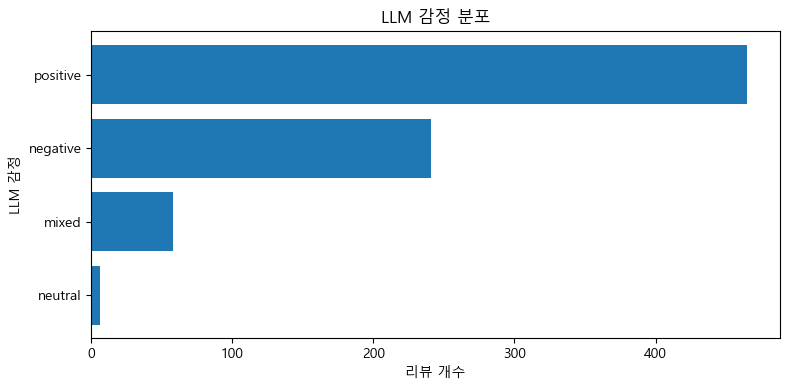

In [10]:
# ============================================================
# 전체 LLM 감정 분포 그래프
# ============================================================

plot_df = llm_sentiment.sort_values("review_count", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(plot_df["llm_sentiment"], plot_df["review_count"])
plt.title("LLM 감정 분포")
plt.xlabel("리뷰 개수")
plt.ylabel("LLM 감정")
plt.tight_layout()
plt.show()

## 분석 목적

이 부분에서는 Steam 추천/비추천 라벨과 LLM 감정 결과를 비교한다.

Steam 라벨은 유저가 최종적으로 추천했는지 여부를 보여주지만, 리뷰 내용 안에는 긍정과 불만이 함께 들어 있을 수 있다.  
따라서 LLM 감정 분포와 시급도까지 함께 보면서, Action 장르 초기 리뷰의 전체 분위기를 먼저 확인한다.


## 결과 해석

분석 대상 리뷰 770개 중 Steam 기준 긍정 리뷰는 511개, 부정 리뷰는 259개로 긍정 리뷰가 더 많았다.  
LLM 기준으로도 긍정 리뷰가 465개로 가장 많았지만, 부정 241개와 혼합 58개도 함께 나타났다.

이는 Action 계열 초기 리뷰가 단순히 “좋다/나쁘다”로만 나뉘지 않는다는 뜻이다.  
추천 리뷰 안에서도 개선 요구가 있을 수 있고, 비추천 리뷰 안에서도 장점 언급이 섞일 수 있다.

또한 High urgency로 분류된 리뷰가 214개로 나타났다.  
따라서 출시 전 분석에서는 긍정률만 보는 것이 아니라, 어떤 문제가 초기 반응을 흔들 수 있는지까지 함께 확인해야 한다.


# 5. 유저가 긍정적으로 평가한 요소

이제 유저가 좋게 평가한 요소를 확인한다.  
다만 `긍정 칭찬`은 너무 일반적인 태그이므로, 실제 개발 체크리스트로 연결할 때는 제외하고 본다.

> 긍정 칭찬이라고 태그 있는데 그 값이 너무 커서 대부분의 값을 잡아먹어 제외

In [11]:
# ============================================================
# 긍정 이슈 태그 TOP 10
# ============================================================
positive_tags = tag_df[
    (tag_df["tag_sentiment"] == "positive") &
    (tag_df["issue_name_kor"] != "긍정 칭찬")
]

positive_top = positive_tags["issue_name_kor"].value_counts().head(10).reset_index()
positive_top.columns = ["긍정 요소", "태그 수"]

display(positive_top)

,긍정 요소,태그 수
0,게임플레이 루프,65
1,그래픽/사운드,37
2,난이도,26
3,스토리,13
4,콘텐츠 분량,12
5,가격/가치,12
6,개발사 소통,9
7,조작감,6
8,기타,5
9,UI/UX,4


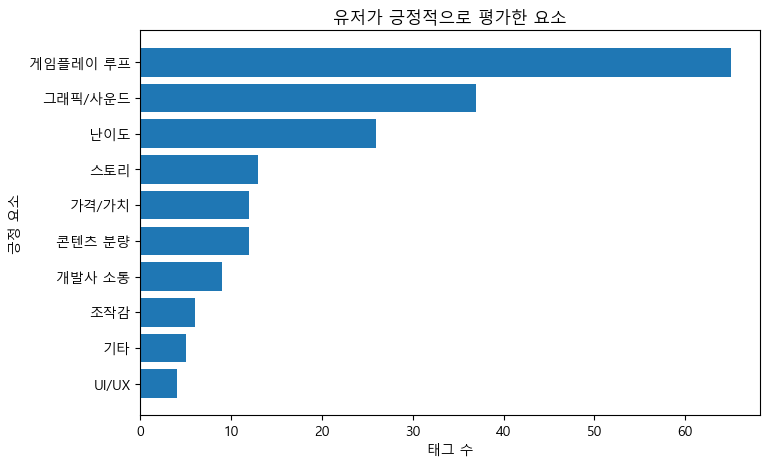

In [12]:
# ============================================================
# 긍정 요소 그래프
# ============================================================

if len(positive_top) > 0:
    plot_df = positive_top.sort_values("태그 수")

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["긍정 요소"], plot_df["태그 수"])
    plt.title("유저가 긍정적으로 평가한 요소")
    plt.xlabel("태그 수")
    plt.ylabel("긍정 요소")
    plt.show()

## 분석 목적

이 부분에서는 유저가 Action 계열 게임에서 좋게 평가한 요소를 확인한다.

긍정 요소는 출시 전 전략에서 “강화해야 할 부분”으로 연결된다.  
즉, 유저가 기존 게임에서 좋아했던 요소를 확인하고, 우리 게임을 출시하기 전에 어떤 강점을 살려야 하는지 정리하는 목적이다.


## 결과 해석

긍정 이슈에서는 **게임플레이 루프**가 가장 많이 나타났다.  
그 다음으로 그래픽/사운드, 난이도, 스토리, 콘텐츠 분량, 가격/가치가 뒤를 이었다.

이 결과는 Action 장르에서 유저가 단순히 “액션 요소가 있다”는 것만으로 만족하지 않는다는 점을 보여준다.  
반복 플레이가 재미있고, 조작과 전투 흐름이 자연스럽고, 분위기와 난이도가 잘 맞을 때 긍정 반응이 만들어진다.

따라서 출시 전에는 기능을 많이 넣는 것보다, 다음 질문을 먼저 확인해야 한다.

| 점검 질문 | 의미 |
|---|---|
| 초반 30분 안에 핵심 재미가 드러나는가? | 첫 플레이에서 게임의 매력을 느끼는지 확인 |
| 반복 플레이가 지루하지 않은가? | 같은 행동을 반복해도 계속할 이유가 있는지 확인 |
| 그래픽/사운드가 장르 분위기를 살리는가? | 액션 경험의 몰입감을 높이는지 확인 |
| 난이도가 불합리하지 않은가? | 어렵더라도 납득 가능한 도전인지 확인 |

즉, 긍정 요소 분석은 출시 전 강화 방향을 **핵심 루프, 분위기, 난이도, 가격 대비 만족감** 중심으로 잡아야 한다는 근거가 된다.


## LLM의 결과 해석

대략 이런 느낌으로 작동하도록 설계할려고 합니다.

In [13]:
# ============================================================
# 긍정 요소를 출시 전 강화 방향으로 연결
# ============================================================

positive_action_map = {
    "게임플레이 루프": "핵심 재미가 초반 30분 안에 드러나는지 점검",
    "그래픽/사운드": "장르 분위기와 몰입감을 충분히 전달하는지 점검",
    "난이도": "어렵더라도 납득 가능한 도전 구조인지 점검",
    "스토리": "초반 몰입 장치와 목표 제시가 충분한지 점검",
    "콘텐츠 분량": "가격대에 맞는 플레이 분량과 반복 동기가 있는지 점검",
    "가격/가치": "유저가 가격 대비 만족감을 느낄 수 있는지 점검",
    "조작감": "이동, 공격, 회피, 상호작용의 반응성이 좋은지 점검",
    "UI/UX": "튜토리얼, 메뉴, 목표 안내가 직관적인지 점검",
    "개발사 소통": "출시 전후 패치 계획과 소통 방식이 준비되어 있는지 점검"
}

positive_report = positive_top.copy()
positive_report["출시 전 강화 방향"] = positive_report["긍정 요소"].map(positive_action_map)
positive_report["출시 전 강화 방향"] = positive_report["출시 전 강화 방향"].fillna("해당 요소가 강점으로 작동하는 이유를 추가 확인")

display(positive_report)

,긍정 요소,태그 수,출시 전 강화 방향
0,게임플레이 루프,65,핵심 재미가 초반 30분 안에 드러나는지 점검
1,그래픽/사운드,37,장르 분위기와 몰입감을 충분히 전달하는지 점검
2,난이도,26,어렵더라도 납득 가능한 도전 구조인지 점검
3,스토리,13,초반 몰입 장치와 목표 제시가 충분한지 점검
4,콘텐츠 분량,12,가격대에 맞는 플레이 분량과 반복 동기가 있는지 점검
5,가격/가치,12,유저가 가격 대비 만족감을 느낄 수 있는지 점검
6,개발사 소통,9,출시 전후 패치 계획과 소통 방식이 준비되어 있는지 점검
7,조작감,6,"이동, 공격, 회피, 상호작용의 반응성이 좋은지 점검"
8,기타,5,해당 요소가 강점으로 작동하는 이유를 추가 확인
9,UI/UX,4,"튜토리얼, 메뉴, 목표 안내가 직관적인지 점검"


# 6. 유저가 부정적으로 평가한 요소

이번에는 유저가 불만을 가진 요소를 확인한다.  
이 결과는 출시 전 **주의할 리스크**로 연결한다.

In [14]:
# ============================================================
# 부정 이슈 태그 TOP 10
# ============================================================

negative_tags = tag_df[tag_df["tag_sentiment"] == "negative"]

negative_top = negative_tags["issue_name_kor"].value_counts().head(10).reset_index()
negative_top.columns = ["부정 요소", "태그 수"]

display(negative_top)

,부정 요소,태그 수
0,게임플레이 루프,156
1,버그,92
2,조작감,68
3,밸런스,63
4,난이도,57
5,UI/UX,56
6,콘텐츠 분량,37
7,그래픽/사운드,37
8,스토리,33
9,기타,32


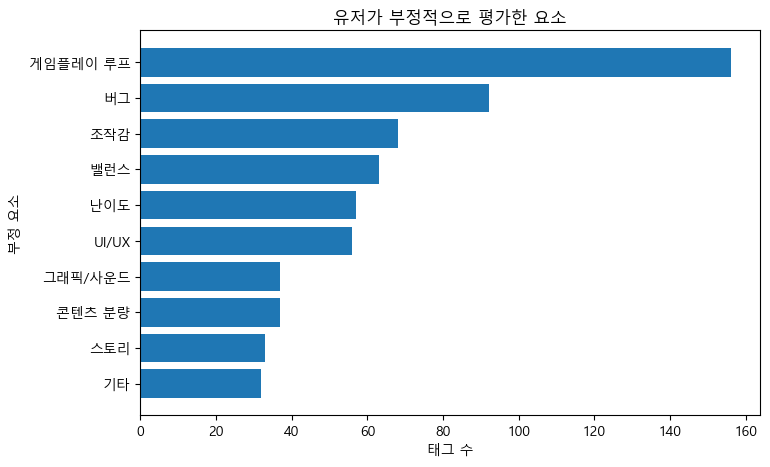

In [15]:
# ============================================================
# 부정 요소 그래프
# ============================================================

if len(negative_top) > 0:
    plot_df = negative_top.sort_values("태그 수")

    plt.figure(figsize=(8, 5))
    plt.barh(plot_df["부정 요소"], plot_df["태그 수"])
    plt.title("유저가 부정적으로 평가한 요소")
    plt.xlabel("태그 수")
    plt.ylabel("부정 요소")
    plt.show()

## 분석 목적

이 부분에서는 유저가 불만을 가진 요소를 확인한다.

부정 요소는 출시 전 전략에서 “미리 피해야 할 리스크”로 연결된다.  
즉, 기존 Action 게임의 초기 리뷰에서 반복적으로 나온 불만을 보고, 출시 전에 어떤 문제를 먼저 줄여야 하는지 확인한다.


## 결과 해석

부정 이슈에서는 **게임플레이 루프**가 가장 많이 나타났다.  
그 다음으로 버그, 조작감, 밸런스, 난이도, UI/UX가 많이 언급되었다.

특히 게임플레이 루프는 긍정 요소에서도 1위였고, 부정 요소에서도 1위였다.  
이는 Action 장르에서 핵심 루프가 잘 만들어지면 강점이 되지만, 지루하거나 목적이 불명확하면 가장 큰 불만이 된다는 뜻이다.

부정 반응의 핵심은 크게 두 가지로 정리할 수 있다.

| 부정 요소 | 출시 전 주의점 |
|---|---|
| 게임플레이 루프 | 반복 플레이가 지루하거나 목적이 약하면 초반 이탈로 이어질 수 있다 |
| 버그 | 출시 초반 평판을 빠르게 떨어뜨릴 수 있다 |
| 조작감 | Action 장르의 핵심 재미를 직접 방해한다 |
| 밸런스/난이도 | 도전감이 아니라 불합리함으로 느껴질 수 있다 |
| UI/UX | 튜토리얼과 목표 안내가 부족하면 진입 장벽이 생긴다 |

따라서 출시 전에는 콘텐츠 추가보다 **버그 제거, 조작감 점검, 핵심 루프 검증, 난이도/밸런스 조정**을 먼저 봐야 한다.


## LLM의 결과 해석

대략 이런 느낌으로 작동하도록 설계할려고 합니다.

In [16]:
# ============================================================
# 부정 요소를 출시 전 리스크로 연결
# ============================================================

negative_risk_map = {
    "게임플레이 루프": "반복 플레이가 지루하거나 목적이 불명확해질 위험",
    "버그": "출시 초반 평판을 빠르게 떨어뜨릴 위험",
    "조작감": "Action 장르의 핵심 재미가 방해받을 위험",
    "밸런스": "어려움이 불공정함으로 느껴질 위험",
    "난이도": "초반 이탈과 피로감을 만들 위험",
    "UI/UX": "튜토리얼 부족, 목표 안내 부족으로 진입 장벽이 생길 위험",
    "그래픽/사운드": "장르 분위기나 품질 기대치에 못 미칠 위험",
    "콘텐츠 분량": "가격 대비 할 것이 부족하다는 불만이 생길 위험",
    "스토리": "몰입감 부족, 전개 불만이 생길 위험",
    "성장/반복 노가다": "반복 플레이가 보상이 아닌 피로감으로 느껴질 위험",
    "저장/진행": "진행 손실 또는 진행 불가로 강한 불만이 생길 위험",
    "크래시": "게임 실행과 진행 자체가 막힐 위험",
    "성능": "프레임, 로딩, 최적화 문제로 플레이 경험이 나빠질 위험",
    "최적화": "기기 환경에 따라 플레이가 불안정해질 위험"
}

negative_report = negative_top.copy()
negative_report["출시 전 주의 리스크"] = negative_report["부정 요소"].map(negative_risk_map)
negative_report["출시 전 주의 리스크"] = negative_report["출시 전 주의 리스크"].fillna("해당 이슈가 부정 반응으로 이어지는 이유를 추가 확인")

display(negative_report)

,부정 요소,태그 수,출시 전 주의 리스크
0,게임플레이 루프,156,반복 플레이가 지루하거나 목적이 불명확해질 위험
1,버그,92,출시 초반 평판을 빠르게 떨어뜨릴 위험
2,조작감,68,Action 장르의 핵심 재미가 방해받을 위험
3,밸런스,63,어려움이 불공정함으로 느껴질 위험
4,난이도,57,초반 이탈과 피로감을 만들 위험
5,UI/UX,56,"튜토리얼 부족, 목표 안내 부족으로 진입 장벽이 생길 위험"
6,콘텐츠 분량,37,가격 대비 할 것이 부족하다는 불만이 생길 위험
7,그래픽/사운드,37,장르 분위기나 품질 기대치에 못 미칠 위험
8,스토리,33,"몰입감 부족, 전개 불만이 생길 위험"
9,기타,32,해당 이슈가 부정 반응으로 이어지는 이유를 추가 확인


# 7. 긍정과 부정이 함께 나타나는 핵심 평가 축

같은 요소가 긍정에도 나오고 부정에도 나온다면,  
그 요소는 단순 장단점이 아니라 **성공과 실패를 가르는 핵심 평가 축**으로 볼 수 있다.

In [17]:
# ============================================================
# 긍정과 부정이 함께 나타나는 핵심 평가 축
# ============================================================

positive_count = (
    positive_tags["issue_name_kor"]
    .value_counts()
    .reset_index()
)

positive_count.columns = ["이슈", "긍정 태그 수"]


negative_count = (
    negative_tags["issue_name_kor"]
    .value_counts()
    .reset_index()
)

negative_count.columns = ["이슈", "부정 태그 수"]


both_issue = positive_count.merge(
    negative_count,
    on="이슈",
    how="inner"
)

both_issue["전체 태그 수"] = both_issue["긍정 태그 수"] + both_issue["부정 태그 수"]

both_issue = both_issue.sort_values("전체 태그 수", ascending=False).head(10)

display(both_issue)

,이슈,긍정 태그 수,부정 태그 수,전체 태그 수
0,게임플레이 루프,65,156,221
2,난이도,26,57,83
1,그래픽/사운드,37,37,74
7,조작감,6,68,74
14,밸런스,1,63,64
9,UI/UX,4,56,60
4,콘텐츠 분량,12,37,49
3,스토리,13,33,46
8,기타,5,32,37
10,성장/반복 노가다,4,28,32


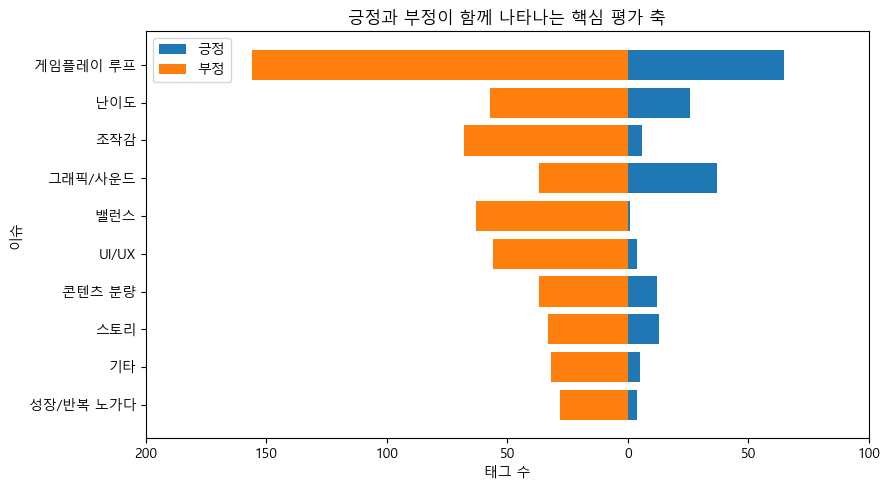

In [18]:
# ============================================================
# 긍정/부정이 함께 나타나는 이슈 그래프
# ============================================================

plot_df = both_issue.sort_values("전체 태그 수", ascending=True)

plt.figure(figsize=(9, 5))

plt.barh(
    plot_df["이슈"],
    plot_df["긍정 태그 수"],
    label="긍정"
)

plt.barh(
    plot_df["이슈"],
    -plot_df["부정 태그 수"],
    label="부정"
)

plt.title("긍정과 부정이 함께 나타나는 핵심 평가 축")
plt.xlabel("태그 수")
plt.ylabel("이슈")
plt.legend()

# x축 숫자는 음수도 양수처럼 보이게 처리
current_ticks = plt.xticks()[0]
new_labels = [abs(int(tick)) for tick in current_ticks]
plt.xticks(current_ticks, new_labels)

plt.tight_layout()
plt.show()

## 분석 목적

이 부분에서는 긍정과 부정에 모두 나타나는 이슈를 확인한다.

같은 이슈가 긍정에도 나오고 부정에도 나온다면, 그 이슈는 단순한 장점이나 단점이 아니다.  
그 요소는 게임의 평가를 좋게 만들 수도 있고 나쁘게 만들 수도 있는 **핵심 평가 축**으로 볼 수 있다.


## 결과 해석

긍정과 부정이 함께 나타나는 이슈는 Action 장르에서 유저 반응을 가르는 **핵심 평가 축**으로 볼 수 있다.

예를 들어 게임플레이 루프, 난이도, 조작감, 그래픽/사운드, 콘텐츠 분량 같은 요소는 잘 구현되면 긍정 요소로 평가되지만, 완성도가 부족하면 부정 이슈로 전환될 수 있다.  
즉, 중요한 것은 “해당 요소를 넣었는가”가 아니라 “유저가 기대하는 수준까지 완성했는가”이다.

Action 장르에서 특히 중요한 평가 축은 다음과 같다.

| 핵심 평가 축 | 잘 구현되었을 때 | 부족할 때 |
|---|---|---|
| 게임플레이 루프 | 반복 플레이가 재미있음 | 반복이 지루하거나 목적이 약함 |
| 조작감 | 손맛과 반응성이 좋음 | 답답하고 불편함 |
| 난이도/밸런스 | 도전감과 몰입감을 만듦 | 불합리함과 피로감을 만듦 |
| UI/UX | 진행과 조작을 쉽게 이해함 | 진입 장벽이 생김 |
| 그래픽/사운드 | 분위기와 몰입감을 높임 | 품질 기대치에 못 미침 |

따라서 출시 전 점검은 기능 추가보다 **핵심 경험의 완성도 검증**을 먼저 해야 한다.


## LLM의 결과 해석

대략 이런 느낌으로 작동하도록 설계할려고 합니다.

In [19]:
# ============================================================
# 핵심 평가 축 해석표
# ============================================================

core_axis_map = {
    "게임플레이 루프": ["반복 플레이가 재미있음", "반복이 지루하거나 목적이 불명확함", "핵심 루프를 초반 플레이 테스트로 검증"],
    "난이도": ["도전적이고 몰입됨", "불합리하고 피곤함", "난이도 곡선과 초반 진입 장벽 점검"],
    "그래픽/사운드": ["분위기와 몰입감이 좋음", "품질 기대치에 못 미침", "장르 분위기 전달력 점검"],
    "콘텐츠 분량": ["할 것이 충분함", "금방 할 것이 없어짐", "가격 대비 분량과 반복 동기 점검"],
    "조작감": ["손맛과 반응성이 좋음", "답답하고 불편함", "컨트롤 반응성 테스트 필수"],
    "밸런스": ["전투나 성장 구조가 적절함", "불공정하거나 피로함", "무기, 적, 보상 밸런스 점검"],
    "UI/UX": ["진행과 조작이 이해하기 쉬움", "안내 부족으로 막힘", "튜토리얼과 목표 안내 점검"],
    "가격/가치": ["가격 대비 만족스러움", "가격 대비 부족함", "가격대와 콘텐츠 기대치 조정"]
}

core_rows = []

for issue, values in core_axis_map.items():
    if issue in both_issue["이슈"].values:
        core_rows.append({
            "평가 축": issue,
            "긍정일 때": values[0],
            "부정일 때": values[1],
            "출시 전 판단": values[2]
        })

core_axis_report = pd.DataFrame(core_rows)

display(core_axis_report)

,평가 축,긍정일 때,부정일 때,출시 전 판단
0,게임플레이 루프,반복 플레이가 재미있음,반복이 지루하거나 목적이 불명확함,핵심 루프를 초반 플레이 테스트로 검증
1,난이도,도전적이고 몰입됨,불합리하고 피곤함,난이도 곡선과 초반 진입 장벽 점검
2,그래픽/사운드,분위기와 몰입감이 좋음,품질 기대치에 못 미침,장르 분위기 전달력 점검
3,콘텐츠 분량,할 것이 충분함,금방 할 것이 없어짐,가격 대비 분량과 반복 동기 점검
4,조작감,손맛과 반응성이 좋음,답답하고 불편함,컨트롤 반응성 테스트 필수
5,밸런스,전투나 성장 구조가 적절함,불공정하거나 피로함,"무기, 적, 보상 밸런스 점검"
6,UI/UX,진행과 조작이 이해하기 쉬움,안내 부족으로 막힘,튜토리얼과 목표 안내 점검


# 8. High urgency 기준 출시 전 리스크

`urgency`는 LLM이 리뷰 내용을 보고 판단한 개선 시급도다.  
여기서는 `high`로 분류된 이슈를 중심으로 출시 전 우선 점검 항목을 정리한다.

In [20]:
# ============================================================
# High urgency 이슈 TOP 10
# ============================================================

high_tags = tag_df[
    (tag_df["urgency"] == "high") &
    (tag_df["issue_name_kor"] != "긍정 칭찬")
]

high_top = high_tags["issue_name_kor"].value_counts().head(10).reset_index()
high_top.columns = ["High urgency 이슈", "태그 수"]

display(high_top)

,High urgency 이슈,태그 수
0,게임플레이 루프,106
1,버그,68
2,밸런스,48
3,조작감,47
4,난이도,39
5,UI/UX,31
6,그래픽/사운드,21
7,저장/진행,21
8,크래시,20
9,스토리,20


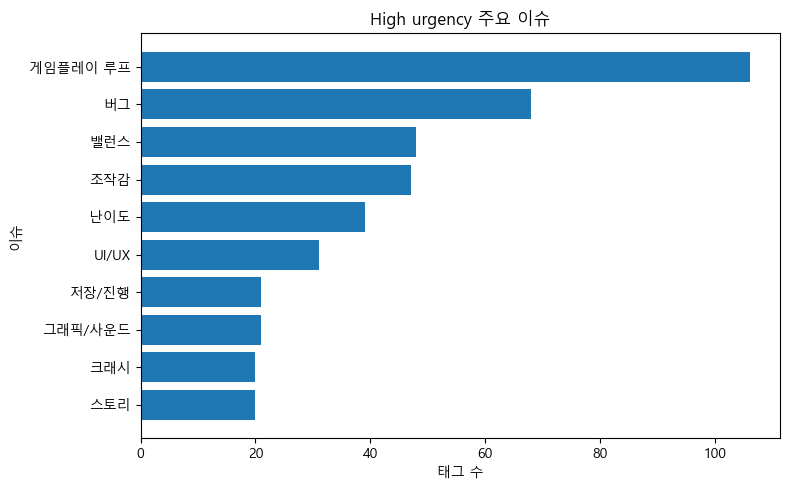

In [21]:
# ============================================================
# High urgency 주요 이슈 그래프
# ============================================================

plot_df = high_top.sort_values("태그 수")

plt.figure(figsize=(8, 5))
plt.barh(plot_df["High urgency 이슈"], plot_df["태그 수"])
plt.title("High urgency 주요 이슈")
plt.xlabel("태그 수")
plt.ylabel("이슈")
plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# 출시 전 점검 우선순위 확인
# ============================================================
# 임의의 가중치를 주지 않고,
# 부정 태그 수와 High urgency 태그 수를 함께 본다.

negative_count = (
    negative_tags["issue_name_kor"]
    .value_counts()
    .reset_index()
)

negative_count.columns = ["이슈", "부정 태그 수"]


high_count = (
    high_tags["issue_name_kor"]
    .value_counts()
    .reset_index()
)

high_count.columns = ["이슈", "High urgency 태그 수"]


priority_table = negative_count.merge(
    high_count,
    on="이슈",
    how="outer"
).fillna(0)

priority_table["부정 태그 수"] = priority_table["부정 태그 수"].astype(int)
priority_table["High urgency 태그 수"] = priority_table["High urgency 태그 수"].astype(int)

priority_table = priority_table.sort_values(
    ["High urgency 태그 수", "부정 태그 수"],
    ascending=False
).head(12)

display(priority_table)

,이슈,부정 태그 수,High urgency 태그 수
3,게임플레이 루프,156,106
9,버그,92,68
8,밸런스,63,48
15,조작감,68,47
6,난이도,57,39
0,UI/UX,56,31
4,그래픽/사운드,37,21
14,저장/진행,23,21
13,스토리,33,20
18,크래시,20,20


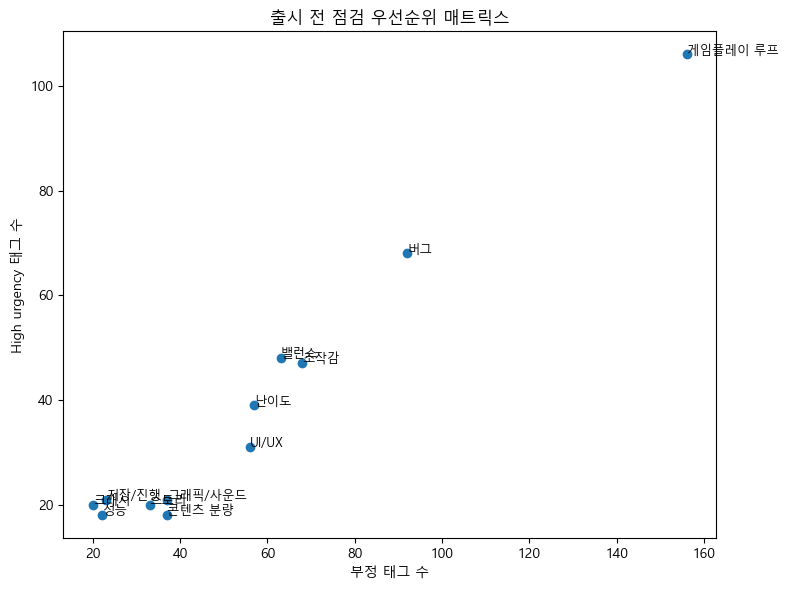

In [23]:
# ============================================================
# 출시 전 점검 우선순위 매트릭스
# ============================================================
# x축: 부정 태그 수
# y축: High urgency 태그 수

plt.figure(figsize=(8, 6))

plt.scatter(
    priority_table["부정 태그 수"],
    priority_table["High urgency 태그 수"]
)

for i in range(len(priority_table)):
    plt.text(
        priority_table["부정 태그 수"].iloc[i],
        priority_table["High urgency 태그 수"].iloc[i],
        priority_table["이슈"].iloc[i],
        fontsize=9
    )

plt.title("출시 전 점검 우선순위 매트릭스")
plt.xlabel("부정 태그 수")
plt.ylabel("High urgency 태그 수")

plt.tight_layout()
plt.show()

## 분석 목적

이 부분에서는 LLM이 High urgency로 분류한 이슈를 중심으로 출시 전 리스크를 정리한다.

High urgency는 리뷰 내용상 문제가 심각하거나, 게임 경험에 큰 영향을 줄 가능성이 높은 이슈를 의미한다.  
따라서 이 분석은 출시 전 개발 우선순위를 정하는 데 사용한다.


## 결과 해석

High urgency 상위 이슈는 출시 후 유저 경험을 크게 흔들 수 있는 리스크로 볼 수 있다.  
이 분석에서는 임의의 점수를 만들기보다, **부정 이슈의 반복성**과 **High urgency 출현 빈도**를 함께 보았다.

그래프에서 오른쪽 위에 가까운 이슈는 다음 두 조건을 동시에 만족한다.

| 기준 | 의미 |
|---|---|
| 부정 태그 수가 많음 | 여러 리뷰에서 반복적으로 불만이 제기됨 |
| High urgency 태그 수가 많음 | LLM이 시급도가 높은 문제로 분류함 |

따라서 오른쪽 위에 위치한 이슈는 출시 전 우선 점검 대상으로 해석할 수 있다.  
반대로 부정 태그 수는 많지만 High urgency가 낮은 이슈는 장기 개선 대상으로, High urgency는 높지만 반복 빈도가 낮은 이슈는 개별 사례 확인 대상으로 볼 수 있다.

출시 전 점검은 다음 흐름으로 정리할 수 있다.

| 우선 점검 영역 | 이유 |
|---|---|
| 게임플레이 루프 | 초반 재미와 반복 플레이를 결정한다 |
| 버그 / 크래시 / 저장 문제 | 게임 진행 자체를 막을 수 있다 |
| 조작감 | Action 장르의 핵심 경험을 직접 결정한다 |
| 밸런스 / 난이도 | 불합리함, 피로감, 초반 이탈로 이어질 수 있다 |
| UI/UX | 튜토리얼 부족과 목표 안내 부족이 진입 장벽이 될 수 있다 |

즉, 이 섹션의 결론은 **기술 안정성 → 조작감 → 핵심 루프 → 난이도/밸런스 → UI/UX** 순서로 출시 전 점검을 구체화해야 한다는 것이다.


# 9. 가격대별 유저 기대 차이

가격대 정보가 있는 경우, 가격대별로 어떤 이슈가 많이 나오는지 확인한다.  
가격대 정보가 없으면 이 섹션은 건너뛴다.

,가격대,리뷰 수
0,0-5,161
1,5-10,282
2,10-20,116
3,20-40,111
4,40+,100


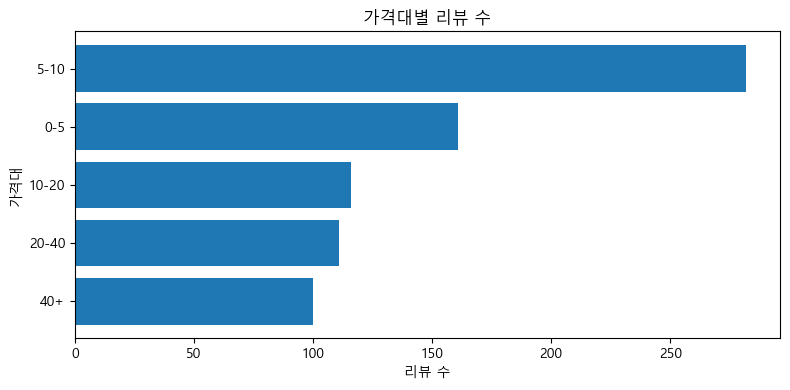

In [24]:
# ============================================================
# 가격대별 리뷰 수 확인
# ============================================================
price_group_order = ["0-5", "5-10", "10-20", "20-40", "40+"]

tag_df["price_group"] = pd.Categorical(
    tag_df["price_group"],
    categories=price_group_order,
    ordered=True
)

price_sample = (
    tag_df
    .groupby("price_group")["recommendationid"]
    .nunique()
    .reset_index()
)

price_sample.columns = ["가격대", "리뷰 수"]

display(price_sample)

plot_df = price_sample.sort_values("리뷰 수", ascending=True)

plt.figure(figsize=(8, 4))

plt.barh(
    plot_df["가격대"],
    plot_df["리뷰 수"]
)

plt.title("가격대별 리뷰 수")
plt.xlabel("리뷰 수")
plt.ylabel("가격대")

plt.tight_layout()
plt.show()

[가격대별 주요 긍정 요소 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
price_group,,,,,,,,,,
0-5,0.0,3.7,0.0,17.4,8.7,0.0,2.5,1.2,2.5,1.9
5-10,0.4,0.7,1.4,5.3,4.3,0.4,3.5,0.0,0.4,1.8
10-20,1.7,2.6,2.6,13.8,3.4,2.6,5.2,3.4,0.9,1.7
20-40,0.0,0.9,1.8,4.5,3.6,0.9,4.5,5.4,0.0,1.8
40+,1.0,0.0,0.0,1.0,3.0,0.0,1.0,1.0,0.0,0.0


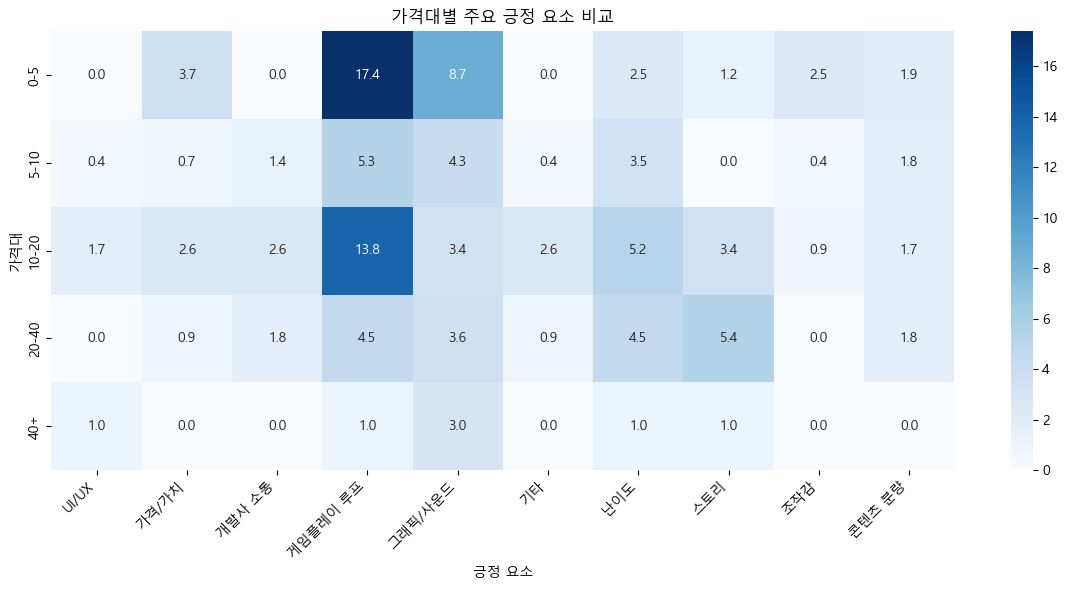

In [25]:
# ============================================================
# 가격대별 주요 긍정 요소 히트맵
# ============================================================
# 가격대별로 어떤 긍정 요소가 자주 나타나는지 확인한다.
# 값은 가격대별 리뷰 수 대비 긍정 이슈 태그 비율이다.
# 단, '긍정 칭찬'은 전반적인 만족 표현에 가까우므로 제외한다.

issue_col = "issue_name_kor"

positive_exclude_keywords = ["긍정 칭찬", "positive praise", "praise"]

price_positive = tag_df[
    (tag_df["tag_sentiment"] == "positive") &
    (tag_df["price_group"].notna()) &
    (tag_df[issue_col].notna())
].copy()

# 전반적인 칭찬 태그 제외
price_positive = price_positive[
    ~price_positive[issue_col].astype(str).str.lower().isin(
        [word.lower() for word in positive_exclude_keywords]
    )
]

# 전체 가격대에서 많이 나온 긍정 요소 상위 10개 선정
top_positive_issues = (
    price_positive[issue_col]
    .value_counts()
    .head(10)
    .index
)

# 가격대별 긍정 이슈 태그 수
price_positive_count = (
    price_positive[price_positive[issue_col].isin(top_positive_issues)]
    .groupby(["price_group", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

# 가격대별 리뷰 수
price_review_count = (
    tag_df
    .groupby("price_group")["recommendationid"]
    .nunique()
)

# 피벗 테이블 생성
price_positive_pivot_count = (
    price_positive_count
    .pivot_table(
        index="price_group",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0
    )
    .reindex(price_group_order)
    .fillna(0)
)

# 가격대별 리뷰 수 대비 비율 계산
price_positive_pivot_rate = (
    price_positive_pivot_count
    .div(price_review_count, axis=0) * 100
)

print("[가격대별 주요 긍정 요소 비율(%)]")
display(price_positive_pivot_rate.round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(
    price_positive_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("가격대별 주요 긍정 요소 비교")
plt.xlabel("긍정 요소")
plt.ylabel("가격대")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [26]:
# ============================================================
# 가격대별 긍정 요소 결과 요약
# ============================================================
positive_result_rows = []

for price_group in price_group_order:
    if price_group not in price_positive_pivot_rate.index:
        continue

    row = price_positive_pivot_rate.loc[price_group].dropna()

    if len(row) == 0 or row.sum() == 0:
        top_issue = "확인 어려움"
        top_rate = 0
    else:
        top_issue = row.idxmax()
        top_rate = row.max()

    positive_result_rows.append({
        "가격대": price_group,
        "주요 긍정 요소": top_issue,
        "리뷰 수 대비 비율(%)": round(top_rate, 1),
    })

price_positive_result_summary = pd.DataFrame(positive_result_rows)

print("[가격대별 긍정 요소 요약]")
display(price_positive_result_summary)

[가격대별 긍정 요소 요약]


,가격대,주요 긍정 요소,리뷰 수 대비 비율(%)
0,0-5,게임플레이 루프,17.4
1,5-10,게임플레이 루프,5.3
2,10-20,게임플레이 루프,13.8
3,20-40,스토리,5.4
4,40+,그래픽/사운드,3.0


[가격대별 주요 부정 이슈 비율(%)]


issue_name_kor,UI/UX,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,스토리,조작감,콘텐츠 분량
price_group,,,,,,,,,,
0-5,3.7,8.7,1.2,2.5,2.5,8.1,4.3,0.0,9.3,2.5
5-10,6.0,26.6,3.2,3.5,11.7,10.3,12.1,2.1,7.1,5.3
10-20,16.4,20.7,8.6,3.4,6.0,7.8,12.1,0.9,12.1,3.4
20-40,8.1,20.7,5.4,1.8,9.9,8.1,7.2,16.2,9.9,2.7
40+,5.0,20.0,10.0,12.0,2.0,3.0,29.0,8.0,8.0,11.0


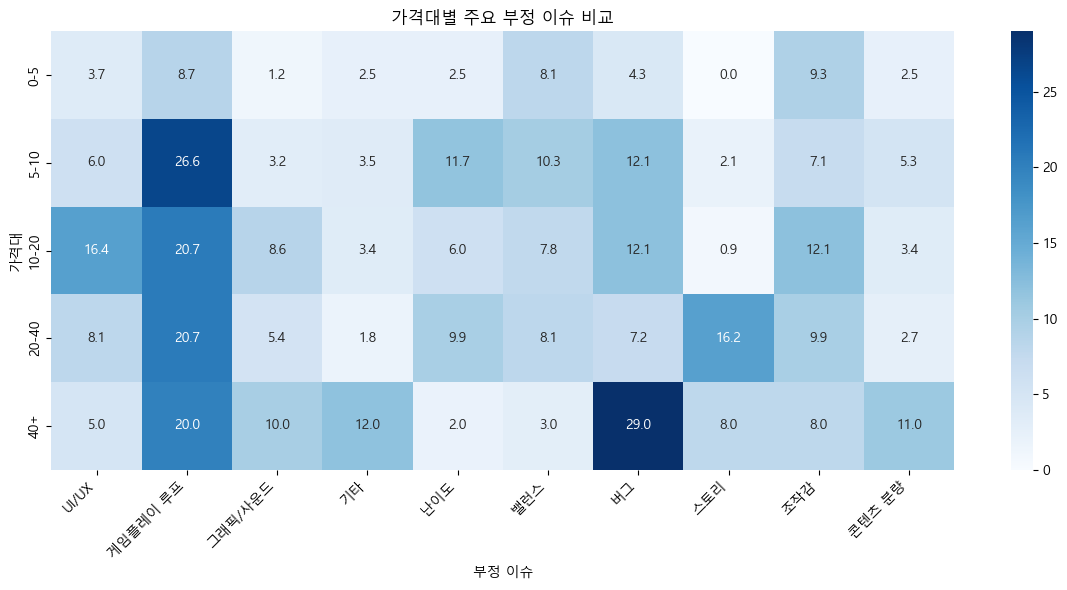

In [27]:
# ============================================================
# 12-3. 가격대별 주요 부정 이슈 히트맵
# ============================================================
# 가격대별로 어떤 부정 이슈가 자주 나타나는지 확인한다.
# 값은 가격대별 리뷰 수 대비 부정 이슈 태그 비율이다.

price_negative = tag_df[
    (tag_df["tag_sentiment"] == "negative") &
    (tag_df["price_group"].notna()) &
    (tag_df[issue_col].notna())
].copy()

# 전체 가격대에서 많이 나온 부정 이슈 상위 10개 선정
top_negative_issues = (
    price_negative[issue_col]
    .value_counts()
    .head(10)
    .index
)

price_negative_count = (
    price_negative[price_negative[issue_col].isin(top_negative_issues)]
    .groupby(["price_group", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

price_negative_pivot_count = (
    price_negative_count
    .pivot_table(
        index="price_group",
        columns=issue_col,
        values="이슈태그수",
        fill_value=0,
    )
    .reindex(price_group_order)
    .fillna(0)
)

# 가격대별 리뷰 수 대비 비율 계산
price_negative_pivot_rate = price_negative_pivot_count.div(price_review_count, axis=0) * 100

print("[가격대별 주요 부정 이슈 비율(%)]")
display(price_negative_pivot_rate.round(1))

plt.figure(figsize=(12, 6))
sns.heatmap(
    price_negative_pivot_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues",
)

plt.title("가격대별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("가격대")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


In [28]:
# ============================================================
# 가격대별 부정 이슈 결과 요약
# ============================================================
# 각 가격대에서 가장 비율이 높은 부정 이슈를 뽑아 요약한다.

negative_result_rows = []

for price_group in price_group_order:
    if price_group not in price_negative_pivot_rate.index:
        continue

    row = price_negative_pivot_rate.loc[price_group].dropna()

    if len(row) == 0 or row.sum() == 0:
        top_issue = "확인 어려움"
        top_rate = 0
    else:
        top_issue = row.idxmax()
        top_rate = row.max()

    negative_result_rows.append({
        "가격대": price_group,
        "주요 부정 이슈": top_issue,
        "리뷰 수 대비 비율(%)": round(top_rate, 1),
    })

price_negative_result_summary = pd.DataFrame(negative_result_rows)

print("[가격대별 부정 이슈 요약]")
display(price_negative_result_summary)

[가격대별 부정 이슈 요약]


,가격대,주요 부정 이슈,리뷰 수 대비 비율(%)
0,0-5,조작감,9.3
1,5-10,게임플레이 루프,26.6
2,10-20,게임플레이 루프,20.7
3,20-40,게임플레이 루프,20.7
4,40+,버그,29.0


## 분석 목적

이 부분에서는 가격대별로 유저가 중요하게 보는 요소가 달라지는지 확인한다.

가격대가 다르면 유저의 기대 수준도 달라질 수 있다.  
저가 게임은 짧더라도 명확한 재미와 가격 대비 만족감이 중요하고, 높은 가격대에서는 버그, 콘텐츠 분량, 완성도에 대한 기대가 커질 수 있다.


## 결과 해석

가격대별 긍정 요소를 보면 낮은 가격대와 중간 가격대에서는 게임플레이 루프가 주요 긍정 요소로 나타났다.  
즉, 유저는 가격이 낮더라도 “짧지만 확실한 재미”와 “반복해서 할 이유”를 중요하게 본다고 해석할 수 있다.

가격이 높아질수록 단순한 재미뿐 아니라 스토리, 그래픽/사운드, 콘텐츠 분량, 기술 안정성에 대한 기대가 커질 수 있다.  
따라서 높은 가격대에서는 핵심 루프뿐 아니라 전체 완성도와 QA 수준을 더 엄격하게 점검해야 한다.

부정 이슈에서는 여러 가격대에서 게임플레이 루프가 반복적으로 나타났다.  
이는 가격과 관계없이 Action 장르의 기본 재미 구조가 초기 평가에 큰 영향을 준다는 뜻이다.

가격대별 출시 전 점검 방향은 다음처럼 정리할 수 있다.

| 가격대 | 출시 전 점검 방향 |
|---|---|
| 0-5 | 조작감과 짧지만 명확한 재미 |
| 5-10 | 핵심 게임플레이 루프와 가격 대비 만족감 |
| 10-20 | 게임플레이 루프, UI/UX, 콘텐츠 흐름 |
| 20-40 | 게임플레이 루프, 스토리, 난이도, 완성도 |
| 40+ | 버그 안정성, 콘텐츠 분량, 그래픽/사운드 완성도 |

이 분석은 가격을 정할 때도 참고할 수 있다.  
가격이 높아질수록 유저는 더 높은 완성도와 안정성을 기대하기 때문에, 출시 전 QA와 콘텐츠 검증이 더 중요해진다.


# 10. Steam 태그별 주요 반응 차이

Steam 태그 정보가 있는 경우, Action 내부에서도 세부 태그에 따라 어떤 문제가 다르게 나타나는지 확인한다.  
태그 정보가 없으면 이 섹션은 건너뛴다.

In [29]:
# ============================================================
# Steam 태그 펼치기
# ============================================================
# 한 리뷰에 여러 Steam 태그가 들어 있으므로, 태그를 하나씩 나눠서 분석하기 쉽게 만든다.

def split_steam_tags(tag_text):
    if pd.isna(tag_text):
        return []
    
    text = str(tag_text)
    
    # 문자열 안에 있는 괄호와 따옴표 제거
    text = text.replace("[", "")
    text = text.replace("]", "")
    text = text.replace("'", "")
    text = text.replace('"', "")
    
    # 쉼표 기준으로 태그 나누기
    tag_list = text.split(",")
    
    # 앞뒤 공백 제거
    tag_list = [tag.strip() for tag in tag_list]
    
    # 빈 문자열 제거
    tag_list = [tag for tag in tag_list if tag != ""]
    
    return tag_list


# tag_df를 복사해서 Steam 태그 분석용 데이터프레임을 만든다.
tag_df_for_steam_tag = tag_df.copy()

# top_steam_tags_text를 리스트로 변환
tag_df_for_steam_tag["steam_tag"] = tag_df_for_steam_tag["top_steam_tags_text"].apply(split_steam_tags)

# 리스트로 들어간 태그를 한 줄씩 펼친다.
tag_df_for_steam_tag = tag_df_for_steam_tag.explode("steam_tag")

# 비어 있는 태그 제거
tag_df_for_steam_tag = tag_df_for_steam_tag.dropna(subset=["steam_tag"])
tag_df_for_steam_tag = tag_df_for_steam_tag[tag_df_for_steam_tag["steam_tag"] != ""]

,Steam 태그,리뷰 수,게임 수
0,Action,366,17
1,Exploration,336,7
2,First-Person,329,7
3,RPG,301,9
4,Open World,286,4
5,2D,267,9
6,Action RPG,262,6
7,Character Customization,254,5
8,Singleplayer,209,4
9,3D,186,7


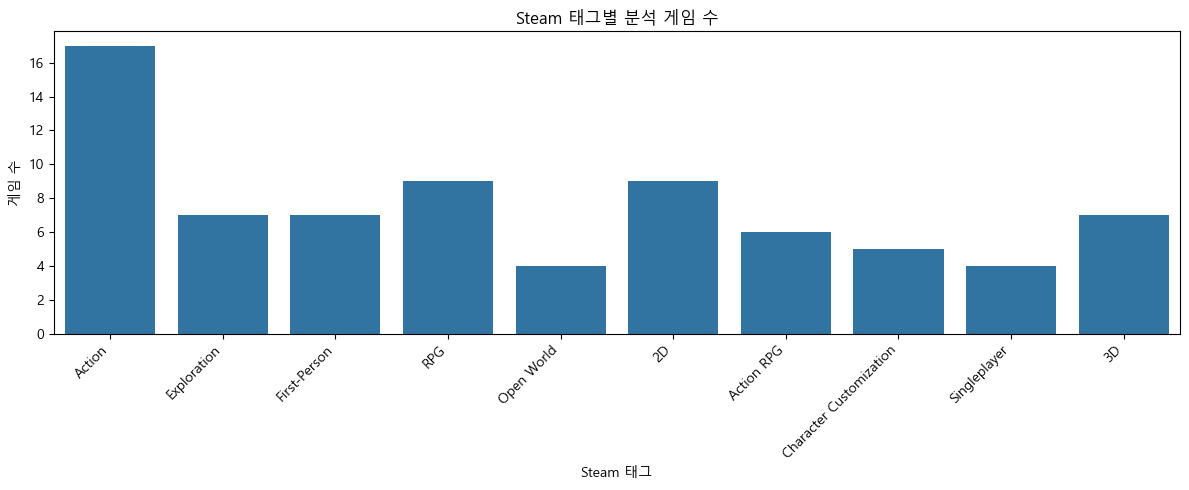

In [30]:
# ============================================================
# 13-0. Steam 태그별 분석 표본 확인
# ============================================================
# Steam 태그별로 리뷰 수와 게임 수를 확인한다.
# 리뷰 수가 많은 상위 10개 태그를 중심으로 분석한다.

issue_col = "issue_name_kor"

# 태그별 리뷰 수 계산
steam_tag_review_count = (
    tag_df_for_steam_tag[["steam_tag", "recommendationid"]]
    .drop_duplicates()
    .groupby("steam_tag")
    .size()
    .sort_values(ascending=False)
)

# 리뷰 수가 많은 상위 10개 태그 선택
top_steam_tags = steam_tag_review_count.head(10).index.tolist()

# 상위 태그의 리뷰 수
steam_tag_review_count_top = steam_tag_review_count.loc[top_steam_tags]

# 상위 태그의 게임 수
steam_tag_game_count = (
    tag_df_for_steam_tag[["steam_tag", "appid"]]
    .drop_duplicates()
    .groupby("steam_tag")["appid"]
    .nunique()
    .loc[top_steam_tags]
)

# 표로 정리
steam_tag_base_summary = pd.DataFrame({
    "Steam 태그": top_steam_tags,
    "리뷰 수": steam_tag_review_count_top.values,
    "게임 수": steam_tag_game_count.values
})

display(steam_tag_base_summary)

# 그래프 출력
plt.figure(figsize=(12, 5))
sns.barplot(
    data=steam_tag_base_summary,
    x="Steam 태그",
    y="게임 수"
)

plt.title("Steam 태그별 분석 게임 수")
plt.xlabel("Steam 태그")
plt.ylabel("게임 수")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

[Steam 태그별 주요 긍정 요소 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
steam_tag,,,,,,,,,,
Action,0.3,1.6,1.4,7.9,3.8,1.1,4.4,0.8,0.5,1.9
Exploration,0.3,0.6,0.6,5.7,5.1,0.3,2.7,2.4,0.3,0.9
First-Person,0.9,0.6,1.5,3.0,4.0,0.0,2.1,0.9,0.0,0.3
RPG,1.0,1.7,1.7,7.3,3.0,0.7,3.3,3.7,0.0,1.0
Open World,0.3,0.7,0.7,2.4,4.9,0.3,2.1,2.4,0.0,1.0
2D,0.4,3.0,0.7,11.6,7.1,1.5,4.9,2.6,1.1,2.2
Action RPG,0.4,0.8,1.1,3.1,2.7,0.4,1.9,2.7,0.0,1.1
Character Customization,0.4,0.4,1.2,5.1,3.5,0.4,3.5,3.5,0.8,2.0
Singleplayer,0.5,1.9,0.0,6.7,6.2,0.0,1.0,0.5,1.4,1.4


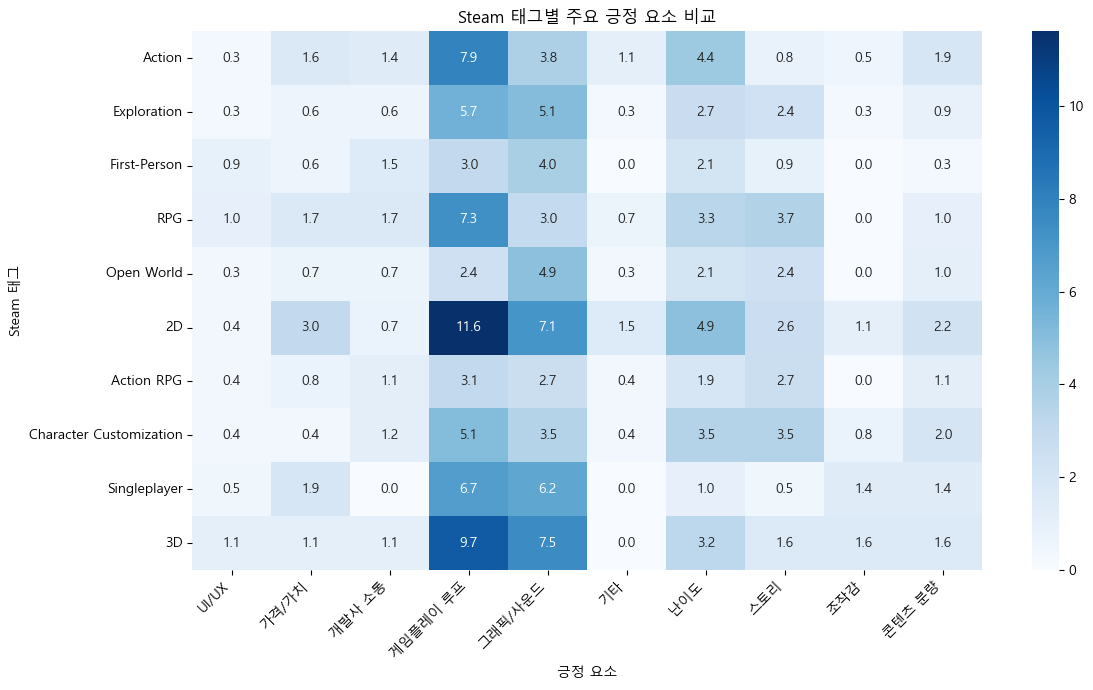

In [31]:
# ============================================================
# 13-1. Steam 태그별 주요 긍정 요소 히트맵
# ============================================================
# Steam 태그별로 어떤 긍정 요소가 많이 나왔는지 확인한다.
# 값은 태그별 리뷰 수 대비 긍정 이슈 태그 비율이다.

positive_exclude_keywords = ["긍정 칭찬", "positive praise", "praise"]

# 긍정 이슈만 선택
steam_positive = tag_df_for_steam_tag[
    (tag_df_for_steam_tag["tag_sentiment"] == "positive") &
    (tag_df_for_steam_tag["steam_tag"].isin(top_steam_tags))
].copy()

# 전반적인 칭찬 태그는 제외
steam_positive = steam_positive[
    ~steam_positive[issue_col].astype(str).str.lower().isin(
        [word.lower() for word in positive_exclude_keywords]
    )
]

# 많이 나온 긍정 요소 상위 10개
top_positive_issues = (
    steam_positive[issue_col]
    .value_counts()
    .head(10)
    .index
)

# 태그별 긍정 요소 개수 계산
steam_positive_count = (
    steam_positive[steam_positive[issue_col].isin(top_positive_issues)]
    .groupby(["steam_tag", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

# 피벗 테이블 만들기
steam_positive_pivot = steam_positive_count.pivot_table(
    index="steam_tag",
    columns=issue_col,
    values="이슈태그수",
    fill_value=0
)

# 태그 순서 정리
steam_positive_pivot = steam_positive_pivot.reindex(top_steam_tags).fillna(0)

# 리뷰 수 대비 비율 계산
steam_positive_rate = steam_positive_pivot.div(steam_tag_review_count_top, axis=0) * 100

print("[Steam 태그별 주요 긍정 요소 비율(%)]")
display(steam_positive_rate.round(1))

plt.figure(figsize=(12, 7))
sns.heatmap(
    steam_positive_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Steam 태그별 주요 긍정 요소 비교")
plt.xlabel("긍정 요소")
plt.ylabel("Steam 태그")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# 13-2. Steam 태그별 주요 긍정 요소 요약
# ============================================================
# 각 Steam 태그에서 가장 비율이 높은 긍정 요소를 뽑는다.

steam_positive_summary = []

for steam_tag in top_steam_tags:
    row = steam_positive_rate.loc[steam_tag]
    
    top_issue = row.idxmax()
    top_rate = row.max()
    
    steam_positive_summary.append({
        "Steam 태그": steam_tag,
        "주요 긍정 요소": top_issue,
        "리뷰 수 대비 비율(%)": round(top_rate, 1)
    })

steam_positive_summary = pd.DataFrame(steam_positive_summary)

display(steam_positive_summary)

,Steam 태그,주요 긍정 요소,리뷰 수 대비 비율(%)
0,Action,게임플레이 루프,7.9
1,Exploration,게임플레이 루프,5.7
2,First-Person,그래픽/사운드,4.0
3,RPG,게임플레이 루프,7.3
4,Open World,그래픽/사운드,4.9
5,2D,게임플레이 루프,11.6
6,Action RPG,게임플레이 루프,3.1
7,Character Customization,게임플레이 루프,5.1
8,Singleplayer,게임플레이 루프,6.7
9,3D,게임플레이 루프,9.7


[Steam 태그별 주요 부정 이슈 비율(%)]


issue_name_kor,UI/UX,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,스토리,조작감,콘텐츠 분량
steam_tag,,,,,,,,,,
Action,7.9,24.3,3.8,3.6,10.9,9.3,10.4,1.6,8.5,5.2
Exploration,6.2,22.0,6.5,5.7,8.0,4.8,16.1,9.5,9.5,4.5
First-Person,8.2,26.4,6.7,5.5,10.9,8.2,20.1,4.6,7.6,6.1
RPG,10.3,20.9,8.0,6.0,5.6,6.0,14.6,9.0,10.0,5.6
Open World,7.0,25.9,8.0,7.0,9.1,5.6,17.1,11.2,9.1,5.2
2D,6.0,15.0,4.1,2.2,6.0,7.9,4.1,6.7,9.0,2.6
Action RPG,5.7,22.9,6.5,7.3,5.0,8.0,14.9,9.9,7.6,8.0
Character Customization,9.1,20.1,7.1,6.7,6.3,4.7,15.4,10.2,11.0,6.3
Singleplayer,4.8,15.8,5.7,7.7,2.4,8.6,17.2,3.8,9.1,7.2


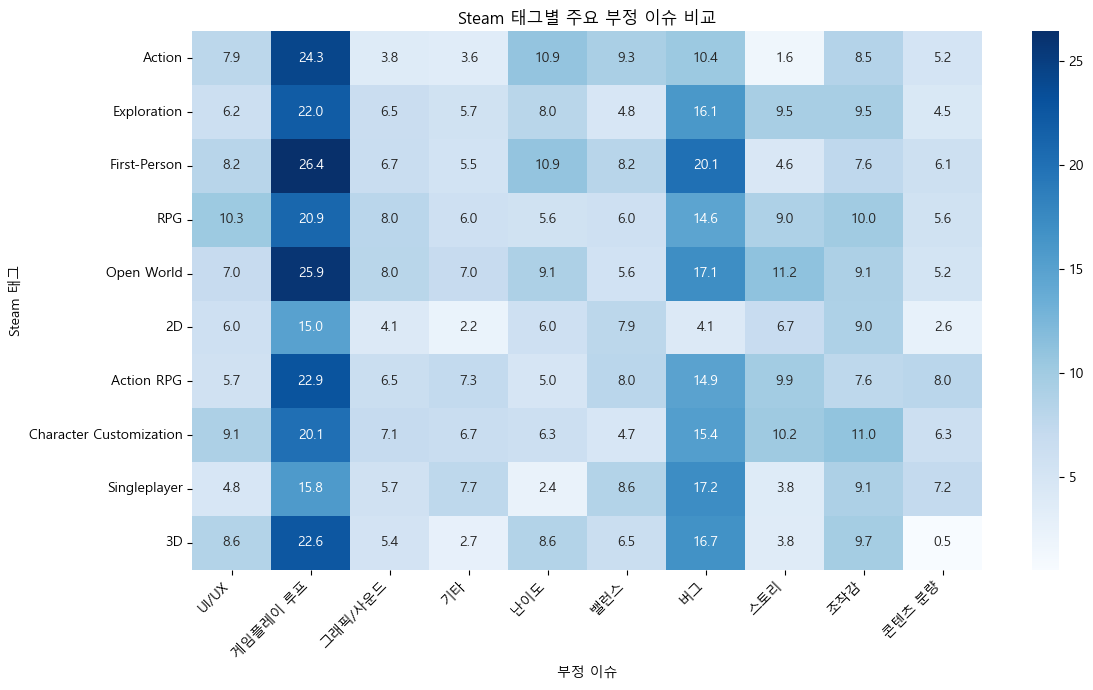

In [33]:
# ============================================================
# 13-3. Steam 태그별 주요 부정 이슈 히트맵
# ============================================================
# Steam 태그별로 어떤 부정 이슈가 많이 나왔는지 확인한다.
# 값은 태그별 리뷰 수 대비 부정 이슈 태그 비율이다.

# 부정 이슈만 선택
steam_negative = tag_df_for_steam_tag[
    (tag_df_for_steam_tag["tag_sentiment"] == "negative") &
    (tag_df_for_steam_tag["steam_tag"].isin(top_steam_tags))
].copy()

# 많이 나온 부정 이슈 상위 10개
top_negative_issues = (
    steam_negative[issue_col]
    .value_counts()
    .head(10)
    .index
)

# 태그별 부정 이슈 개수 계산
steam_negative_count = (
    steam_negative[steam_negative[issue_col].isin(top_negative_issues)]
    .groupby(["steam_tag", issue_col])
    .size()
    .reset_index(name="이슈태그수")
)

# 피벗 테이블 만들기
steam_negative_pivot = steam_negative_count.pivot_table(
    index="steam_tag",
    columns=issue_col,
    values="이슈태그수",
    fill_value=0
)

# 태그 순서 정리
steam_negative_pivot = steam_negative_pivot.reindex(top_steam_tags).fillna(0)

# 리뷰 수 대비 비율 계산
steam_negative_rate = steam_negative_pivot.div(steam_tag_review_count_top, axis=0) * 100

print("[Steam 태그별 주요 부정 이슈 비율(%)]")
display(steam_negative_rate.round(1))

plt.figure(figsize=(12, 7))
sns.heatmap(
    steam_negative_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("Steam 태그별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("Steam 태그")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [34]:
# ============================================================
# 10 Steam 태그별 주요 부정 이슈 요약
# ============================================================
# 각 Steam 태그에서 가장 비율이 높은 부정 이슈를 뽑는다.

steam_negative_summary = []

for steam_tag in top_steam_tags:
    row = steam_negative_rate.loc[steam_tag]
    
    top_issue = row.idxmax()
    top_rate = row.max()
    
    steam_negative_summary.append({
        "Steam 태그": steam_tag,
        "주요 부정 이슈": top_issue,
        "리뷰 수 대비 비율(%)": round(top_rate, 1)
    })

steam_negative_summary = pd.DataFrame(steam_negative_summary)

display(steam_negative_summary)

,Steam 태그,주요 부정 이슈,리뷰 수 대비 비율(%)
0,Action,게임플레이 루프,24.3
1,Exploration,게임플레이 루프,22.0
2,First-Person,게임플레이 루프,26.4
3,RPG,게임플레이 루프,20.9
4,Open World,게임플레이 루프,25.9
5,2D,게임플레이 루프,15.0
6,Action RPG,게임플레이 루프,22.9
7,Character Customization,게임플레이 루프,20.1
8,Singleplayer,버그,17.2
9,3D,게임플레이 루프,22.6


## 분석 목적

이 부분에서는 Action 장르 안에서도 Steam 태그에 따라 유저 반응이 어떻게 달라지는지 확인한다.

Action이라는 큰 장르 안에는 Exploration, First-Person, RPG, Open World, 2D, Action RPG처럼 서로 다른 성격의 게임이 섞여 있다.  
따라서 Steam 태그별 분석은 출시 전 체크리스트를 세부 장르에 맞게 조정하기 위한 보조 분석이다.


## 결과 해석

Steam 태그별 분석에서는 Action, Exploration, First-Person, RPG, Open World, 2D, Action RPG 등이 상위 태그로 나타났다.

긍정 요소를 보면 여러 태그에서 게임플레이 루프와 그래픽/사운드가 반복적으로 나타났다.  
특히 2D와 3D 태그에서는 게임플레이 루프와 그래픽/사운드가 비교적 높게 나타나, 플레이 감각과 시각적 완성도가 중요하게 작동한다고 볼 수 있다.

Steam 태그별 분석의 핵심은 “Action 게임이라면 모두 같은 기준으로 보면 안 된다”는 점이다.  
예를 들어 RPG나 Action RPG 성격이 강하면 성장 구조와 스토리가 중요해질 수 있고, First-Person이나 3D 성격이 강하면 조작감과 몰입감이 더 중요해질 수 있다.

따라서 이 결과는 최종 체크리스트를 세부 태그에 맞게 조정할 때 활용한다.

| 태그 방향 | 출시 전 추가 점검 |
|---|---|
| RPG / Action RPG | 성장 구조, 스토리, 반복 플레이 |
| Open World / Exploration | 탐험 동기, 이동 흐름, 콘텐츠 밀도 |
| First-Person / 3D | 조작감, 시야, 몰입감, 멀미 가능성 |
| 2D | 조작 반응성, 난이도, 시각적 가독성 |
| Singleplayer | 초반 몰입, 콘텐츠 분량, 진행 안내 |


# 11. 플레이 방식별 주요 반응 차이  
카테고리 정보가 있는 경우, 싱글/멀티/협동 여부에 따라 주요 이슈가 달라지는지 확인한다.  

In [35]:
# ============================================================
# 플레이 방식 간단 분류
# ============================================================
# categories_text에 Co-op, Multi-player, Online이 들어가면
# 멀티/협동 요소가 있는 게임으로 분류한다.

review_df["categories_text"] = review_df["categories_text"].fillna("").astype(str)

review_df["play_style"] = "Single-player 중심"

review_df.loc[
    review_df["categories_text"].str.contains("Co-op|Multi-player|Online", case=False, regex=True),
    "play_style"
] = "멀티/협동 요소 포함"

tag_df = tag_df.merge(
    review_df[["recommendationid", "play_style"]].drop_duplicates("recommendationid"),
    on="recommendationid",
    how="left"
)

play_sample = (
    review_df
    .groupby("play_style")["recommendationid"]
    .nunique()
    .reset_index()
)

play_sample.columns = ["플레이 방식", "리뷰 수"]

display(play_sample)

,플레이 방식,리뷰 수
0,Single-player 중심,593
1,멀티/협동 요소 포함,177


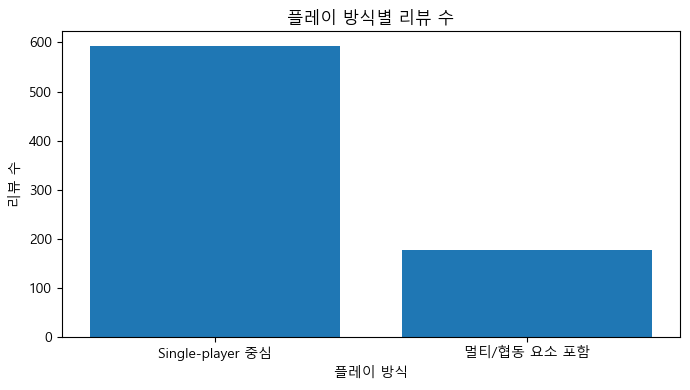

In [36]:
# ============================================================
# 플레이 방식별 리뷰 수 그래프
# ============================================================

plt.figure(figsize=(7, 4))

plt.bar(
    play_sample["플레이 방식"],
    play_sample["리뷰 수"]
)

plt.title("플레이 방식별 리뷰 수")
plt.xlabel("플레이 방식")
plt.ylabel("리뷰 수")

plt.tight_layout()
plt.show()

[플레이 방식별 주요 긍정 요소 비율(%)]


issue_name_kor,UI/UX,가격/가치,개발사 소통,게임플레이 루프,그래픽/사운드,기타,난이도,스토리,조작감,콘텐츠 분량
play_style,,,,,,,,,,
Single-player 중심,0.7,1.7,0.8,8.9,6.1,0.3,2.7,1.9,0.8,1.9
멀티/협동 요소 포함,0.0,1.1,2.3,6.8,0.6,1.7,5.6,1.1,0.6,0.6


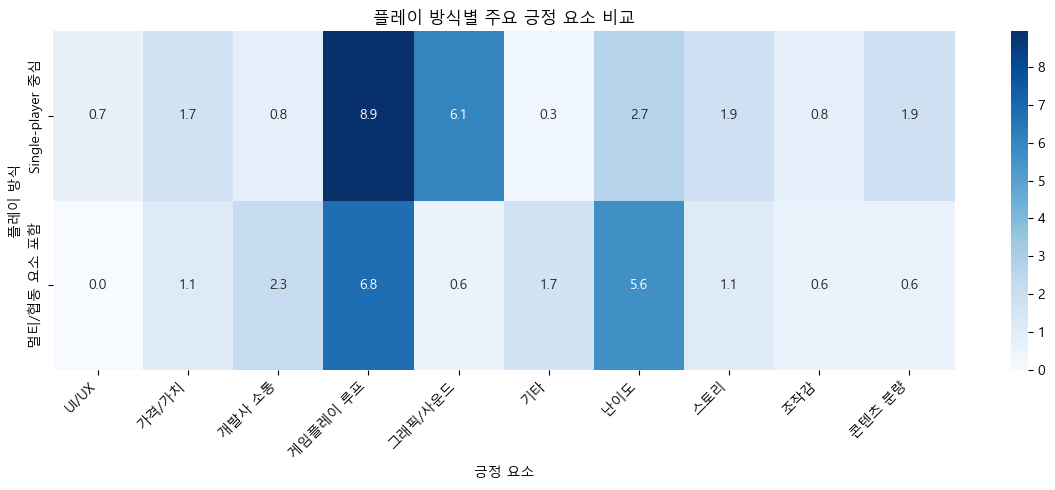

In [37]:
# ============================================================
# 플레이 방식별 주요 긍정 요소 히트맵
# ============================================================
# 플레이 방식별로 어떤 긍정 요소가 자주 나타나는지 확인한다.
# 값은 플레이 방식별 리뷰 수 대비 긍정 이슈 태그 비율이다.

positive_exclude_keywords = ["긍정 칭찬", "positive praise", "praise"]

play_positive = tag_df[
    (tag_df["tag_sentiment"] == "positive") &
    (tag_df["play_style"].notna()) &
    (tag_df["issue_name_kor"].notna())
].copy()

# 전반적인 칭찬 태그는 제외
play_positive = play_positive[
    ~play_positive["issue_name_kor"].astype(str).str.lower().isin(
        [word.lower() for word in positive_exclude_keywords]
    )
]

# 많이 나온 긍정 요소 상위 10개
top_positive_issues = (
    play_positive["issue_name_kor"]
    .value_counts()
    .head(10)
    .index
)

# 플레이 방식별 긍정 이슈 태그 수 계산
play_positive_count = (
    play_positive[play_positive["issue_name_kor"].isin(top_positive_issues)]
    .groupby(["play_style", "issue_name_kor"])
    .size()
    .reset_index(name="이슈태그수")
)

# 피벗 테이블 만들기
play_positive_pivot = play_positive_count.pivot_table(
    index="play_style",
    columns="issue_name_kor",
    values="이슈태그수",
    fill_value=0
)

# 플레이 방식별 리뷰 수 계산
play_review_count = (
    tag_df
    .groupby("play_style")["recommendationid"]
    .nunique()
)

# 리뷰 수 대비 비율 계산
play_positive_rate = play_positive_pivot.div(play_review_count, axis=0) * 100

print("[플레이 방식별 주요 긍정 요소 비율(%)]")
display(play_positive_rate.round(1))

plt.figure(figsize=(12, 5))
sns.heatmap(
    play_positive_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("플레이 방식별 주요 긍정 요소 비교")
plt.xlabel("긍정 요소")
plt.ylabel("플레이 방식")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

[플레이 방식별 주요 부정 이슈 비율(%)]


issue_name_kor,UI/UX,게임플레이 루프,그래픽/사운드,기타,난이도,밸런스,버그,스토리,조작감,콘텐츠 분량
play_style,,,,,,,,,,
Single-player 중심,6.4,19.6,4.9,4.6,5.6,7.8,12.6,5.6,7.9,4.6
멀티/협동 요소 포함,10.2,22.6,4.5,2.8,13.6,9.6,9.6,0.0,11.9,5.6


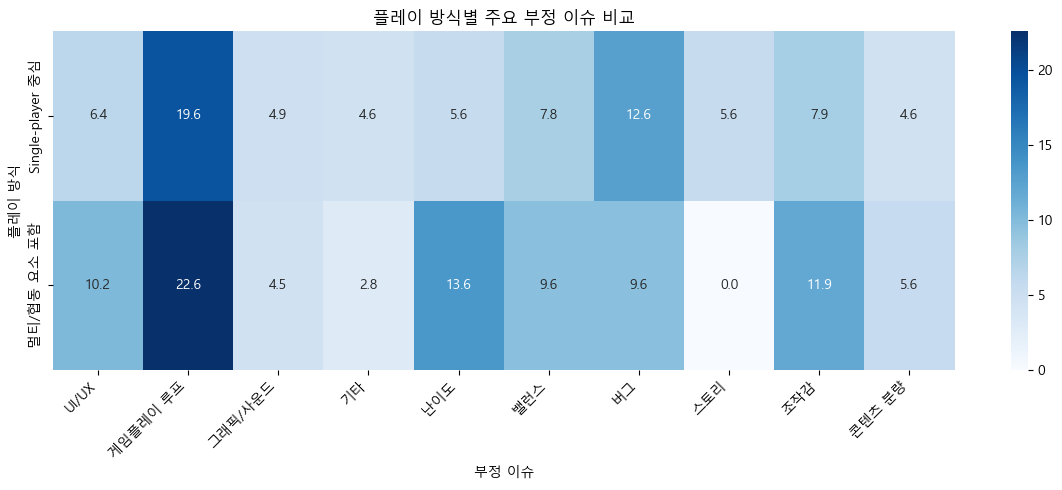

In [38]:
# ============================================================
# 플레이 방식별 주요 부정 이슈 히트맵
# ============================================================
# 플레이 방식별로 어떤 부정 이슈가 자주 나타나는지 확인한다.
# 값은 플레이 방식별 리뷰 수 대비 부정 이슈 태그 비율이다.

play_negative = tag_df[
    (tag_df["tag_sentiment"] == "negative") &
    (tag_df["play_style"].notna()) &
    (tag_df["issue_name_kor"].notna())
].copy()

# 많이 나온 부정 이슈 상위 10개
top_negative_issues = (
    play_negative["issue_name_kor"]
    .value_counts()
    .head(10)
    .index
)

# 플레이 방식별 부정 이슈 태그 수 계산
play_negative_count = (
    play_negative[play_negative["issue_name_kor"].isin(top_negative_issues)]
    .groupby(["play_style", "issue_name_kor"])
    .size()
    .reset_index(name="이슈태그수")
)

# 피벗 테이블 만들기
play_negative_pivot = play_negative_count.pivot_table(
    index="play_style",
    columns="issue_name_kor",
    values="이슈태그수",
    fill_value=0
)

# 리뷰 수 대비 비율 계산
play_negative_rate = play_negative_pivot.div(play_review_count, axis=0) * 100

print("[플레이 방식별 주요 부정 이슈 비율(%)]")
display(play_negative_rate.round(1))

plt.figure(figsize=(12, 5))
sns.heatmap(
    play_negative_rate,
    annot=True,
    fmt=".1f",
    cmap="Blues"
)

plt.title("플레이 방식별 주요 부정 이슈 비교")
plt.xlabel("부정 이슈")
plt.ylabel("플레이 방식")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 분석 목적

플레이 방식에 따라 유저가 중요하게 보는 요소가 달라지는지 확인한다.

Action 장르라도 Single-player 중심 게임과 멀티/협동 요소가 있는 게임은 기대 경험이 다를 수 있다.  
따라서 플레이 방식별 긍정 요소와 부정 이슈를 비교하여, 출시 전 어떤 부분을 더 중점적으로 점검해야 하는지 확인한다.

## 결과 해석

플레이 방식별로 보면 Single-player 중심 리뷰가 593개, 멀티/협동 요소 포함 리뷰가 177개로 나타났다.  
따라서 이번 표본에서는 싱글플레이 중심 게임의 비중이 더 크다.

긍정 요소에서는 두 그룹 모두 게임플레이 루프가 중요하게 나타났다.  
다만 Single-player 중심에서는 그래픽/사운드도 비교적 높게 나타났고, 멀티/협동 요소 포함에서는 난이도와 개발사 소통이 더 눈에 띄었다.

부정 이슈에서는 두 그룹 모두 게임플레이 루프가 높게 나타났다.  
멀티/협동 요소 포함 게임에서는 UI/UX, 난이도, 조작감, 밸런스도 상대적으로 크게 나타났다.

따라서 플레이 방식별 출시 전 점검은 다음처럼 나눌 수 있다.

| 플레이 방식 | 더 중요하게 볼 점 |
|---|---|
| Single-player 중심 | 핵심 루프, 그래픽/사운드, 콘텐츠 분량, 스토리, 초반 안내 |
| 멀티/협동 요소 포함 | 핵심 루프, 난이도, 조작감, 밸런스, UI/UX, 협동 플레이 안정성 |

즉, 같은 Action 게임이라도 싱글 중심인지, 멀티/협동 요소가 있는지에 따라 출시 전 우선 점검 항목이 달라져야 한다.


# 12. 출시 전 개발 체크리스트

## 분석 목적

지금까지의 LLM 분석 결과를 바탕으로 출시 전 점검 항목을 정리한다.

이 섹션은 두 가지 형태로 구성한다.

1. **마크다운 정리표**: 보고서와 PPT에 바로 넣기 쉬운 형태
2. **코드로 만든 표**: 노트북에서 재사용하거나 수정하기 쉬운 형태

이 표가 Part 2의 최종 결과물이다.


## 12-1. 출시 전 개발 체크리스트

| 구분 | 체크 질문 | 우선순위 | 근거 이슈 |
|---|---|---|---|
| 기술 안정성 | 크래시, 저장 오류, 진행 불가 버그가 없는가? | 최상 | 버그, 크래시, 저장/진행 |
| 기술 안정성 | 출시 초반에 반복적으로 발생할 만한 치명적 버그를 제거했는가? | 최상 | 버그, 크래시 |
| 조작감 | 이동, 공격, 회피, 상호작용이 즉각적으로 반응하는가? | 최상 | 조작감 |
| 핵심 루프 | 초반 30분 안에 게임의 핵심 재미가 드러나는가? | 상 | 게임플레이 루프 |
| 난이도 | 어려움이 불합리함이 아니라 도전감으로 느껴지는가? | 상 | 난이도 |
| 밸런스 | 무기, 적, 보상, 성장 구조가 과도하게 불편하지 않은가? | 상 | 밸런스 |
| UI/UX | 튜토리얼, 목표 안내, 메뉴 구조가 이해하기 쉬운가? | 중상 | UI/UX |
| 콘텐츠 분량 | 가격대에 맞는 분량과 반복 플레이 이유가 있는가? | 중 | 콘텐츠 분량 |
| 그래픽/사운드 | 장르 분위기와 기대 수준에 맞는 몰입감을 제공하는가? | 중 | 그래픽/사운드 |
| 가격 대비 가치 | 유저가 이 가격이면 납득된다고 느낄 수 있는가? | 중 | 가격/가치 |


## 12-2. 체크리스트 해석

출시 전 체크리스트의 핵심은 **기술 안정성, 조작감, 핵심 루프**를 먼저 보는 것이다.

Action 장르는 조작과 전투 경험이 중요하기 때문에, 버그나 조작 불편이 있으면 유저가 게임의 재미를 느끼기 전에 이탈할 수 있다.  
따라서 출시 직전에는 새로운 콘텐츠를 더 추가하는 것보다, 이미 구현된 핵심 경험이 안정적으로 작동하는지 확인하는 것이 더 중요하다.

정리하면 우선순위는 다음과 같다.

| 순서 | 우선 점검 영역 | 이유 |
|---|---|---|
| 1 | 버그 / 크래시 / 저장 문제 | 게임 진행 자체를 막을 수 있기 때문 |
| 2 | 조작감 / 전투 반응성 | Action 장르의 핵심 경험이기 때문 |
| 3 | 게임플레이 루프 | 초기 재미와 반복 플레이를 결정하기 때문 |
| 4 | 난이도 / 밸런스 | 도전감과 불합리함의 경계를 결정하기 때문 |
| 5 | UI/UX / 콘텐츠 분량 / 가격 기대치 | 초반 진입 장벽과 가격 대비 만족도에 영향을 주기 때문 |

# 13. LLM을 사용한 체크리스트 자동화
앞의 분석은 사람이 직접 리뷰를 모두 읽지 않아도, LLM이 분류한 감정·이슈 태그·urgency·개선 제안을 바탕으로 유저 반응의 원인을 정리하기 위한 과정이다.

체크리스트는 크게 두 가지 기준을 함께 사용한다.

| 구분 | 의미 | 체크리스트 반영 방식 |
|---|---|---|
| 공통요소 | Action 장르 전체에서 반복적으로 나타난 긍정/부정 이슈 | 모든 Action 게임에 기본으로 들어가는 점검 항목 |
| 개별요소 | 개발자가 입력한 가격대, Steam 태그, 플레이 방식 | 개발자 게임 조건에 맞춰 달라지는 맞춤 점검 항목 |

즉, 최종 목표는 단순히 이슈를 나열하는 것 보단,     
**개발자가 입력한 게임 조건에 맞춰 LLM이 강화할 요소, 주의할 리스크, 개발 우선순위를 자동으로 정리하는 것**이다.

In [39]:
# ============================================================
# 개발자 입력 조건 설정
# ============================================================

target_price_group = "10-20"
target_steam_tags = ["Roguelike", "Action"]
target_play_style = "Single-player 중심"

print("개발자 입력 조건")
print("가격대:", target_price_group)
print("Steam 태그:", target_steam_tags)
print("플레이 방식:", target_play_style)


개발자 입력 조건
가격대: 10-20
Steam 태그: ['Roguelike', 'Action']
플레이 방식: Single-player 중심


In [40]:
# ============================================================
# 15-2. 체크리스트 생성을 위한 공통 이슈 요약
# ============================================================
# Action 장르 전체에서 반복적으로 나타난 이슈를 정리한다.

positive_summary = (
    tag_df[tag_df["tag_sentiment"] == "positive"]["issue_name_kor"]
    .value_counts()
    .head(8)
    .reset_index()
)

positive_summary.columns = ["이슈", "긍정 태그 수"]


negative_summary = (
    tag_df[tag_df["tag_sentiment"] == "negative"]["issue_name_kor"]
    .value_counts()
    .head(8)
    .reset_index()
)

negative_summary.columns = ["이슈", "부정 태그 수"]


high_summary = (
    tag_df[tag_df["urgency"] == "high"]["issue_name_kor"]
    .value_counts()
    .head(8)
    .reset_index()
)

high_summary.columns = ["이슈", "High urgency 태그 수"]


print("[공통 긍정 요소]")
display(positive_summary)

print("[공통 부정 이슈]")
display(negative_summary)

print("[공통 High urgency 이슈]")
display(high_summary)

[공통 긍정 요소]


,이슈,긍정 태그 수
0,긍정 칭찬,463
1,게임플레이 루프,65
2,그래픽/사운드,37
3,난이도,26
4,스토리,13
5,콘텐츠 분량,12
6,가격/가치,12
7,개발사 소통,9


[공통 부정 이슈]


,이슈,부정 태그 수
0,게임플레이 루프,156
1,버그,92
2,조작감,68
3,밸런스,63
4,난이도,57
5,UI/UX,56
6,콘텐츠 분량,37
7,그래픽/사운드,37


[공통 High urgency 이슈]


,이슈,High urgency 태그 수
0,게임플레이 루프,106
1,버그,68
2,밸런스,48
3,조작감,47
4,긍정 칭찬,40
5,난이도,39
6,UI/UX,31
7,그래픽/사운드,21


In [ ]:
# ============================================================
# 개발자 입력 조건에 맞는 개별 이슈 요약
# ============================================================
# 가격대, Steam 태그, 플레이 방식 조건에 맞는 리뷰 태그만 골라본다.

custom_tag = tag_df.copy()

# 가격대 조건 적용
custom_tag = custom_tag[custom_tag["price_group"] == target_price_group]

# 플레이 방식 조건 적용
custom_tag = custom_tag[custom_tag["play_style"] == target_play_style]

# Steam 태그 조건 적용
# Steam 태그는 한 리뷰에 여러 개가 붙어 있으므로,
# 앞에서 만든 tag_df_for_steam_tag를 사용한다.
custom_steam_tag = tag_df_for_steam_tag[
    tag_df_for_steam_tag["steam_tag"].isin(target_steam_tags)
].copy()

# 가격대와 플레이 방식도 함께 맞춘다.
custom_steam_tag = custom_steam_tag[custom_steam_tag["price_group"] == target_price_group]
custom_steam_tag = custom_steam_tag[custom_steam_tag["play_style"] == target_play_style]

print("조건에 맞는 기본 태그 수:", len(custom_tag))
print("조건에 맞는 Steam 태그 펼친 행 수:", len(custom_steam_tag))


KeyError: 'play_style'

In [ ]:
# ============================================================
# 15-4. 조건별 긍정/부정/High urgency 이슈 요약
# ============================================================

custom_positive_summary = (
    custom_steam_tag[custom_steam_tag["tag_sentiment"] == "positive"]["issue_name_kor"]
    .value_counts()
    .head(8)
    .reset_index()
)

custom_positive_summary.columns = ["이슈", "긍정 태그 수"]


custom_negative_summary = (
    custom_steam_tag[custom_steam_tag["tag_sentiment"] == "negative"]["issue_name_kor"]
    .value_counts()
    .head(8)
    .reset_index()
)

custom_negative_summary.columns = ["이슈", "부정 태그 수"]


custom_high_summary = (
    custom_steam_tag[custom_steam_tag["urgency"] == "high"]["issue_name_kor"]
    .value_counts()
    .head(8)
    .reset_index()
)

custom_high_summary.columns = ["이슈", "High urgency 태그 수"]


print("[조건별 긍정 요소]")
display(custom_positive_summary)

print("[조건별 부정 이슈]")
display(custom_negative_summary)

print("[조건별 High urgency 이슈]")
display(custom_high_summary)


In [ ]:
# ============================================================
# 15-5. LLM에게 보낼 개선 제안 예시 추출
# ============================================================
# 기존 LLM 분석 결과에 들어 있는 suggested_action을 체크리스트 문장 생성에 활용한다.

action_examples = (
    review_df[["primary_issue", "urgency", "suggested_action"]]
    .dropna()
    .drop_duplicates()
    .head(20)
)

display(action_examples)


In [ ]:
# ============================================================
# 체크리스트 생성용 프롬프트 만들기
# ============================================================
# 이 프롬프트를 LLM에게 보내면 출시 전 체크리스트 초안을 받을 수 있다.

def table_to_text(df):
    if len(df) == 0:
        return "해당 조건에서 확인된 이슈 없음"
    return df.to_string(index=False)


checklist_prompt = f"""
당신은 인디게임 개발사를 위한 출시 전 체크리스트 작성 도우미입니다.

아래 분석 결과를 바탕으로, 개발자가 출시 전에 확인해야 할 체크리스트를 작성하세요.

[개발자 입력 조건]
- 장르: Action
- 가격대: {target_price_group}
- Steam 태그: {", ".join(target_steam_tags)}
- 플레이 방식: {target_play_style}

[공통 긍정 요소]
{table_to_text(positive_summary)}

[공통 부정 이슈]
{table_to_text(negative_summary)}

[공통 High urgency 이슈]
{table_to_text(high_summary)}

[조건별 긍정 요소]
{table_to_text(custom_positive_summary)}

[조건별 부정 이슈]
{table_to_text(custom_negative_summary)}

[조건별 High urgency 이슈]
{table_to_text(custom_high_summary)}

[LLM 개선 제안 예시]
{table_to_text(action_examples)}

[작성 기준]
1. 공통요소는 Action 장르라면 기본적으로 확인해야 하는 항목입니다.
2. 개별요소는 개발자 입력 조건에 맞춰 더 중요하게 봐야 하는 항목입니다.
3. 반복적으로 등장한 긍정 요소는 '강화할 요소'로 정리하세요.
4. 반복적으로 등장한 부정 이슈는 '주의할 리스크'로 정리하세요.
5. High urgency 이슈는 우선순위를 높게 두세요.
6. suggested_action은 체크 질문 문장을 만들 때 참고하세요.

[출력 형식]
마크다운 표로 작성하세요.

컬럼:
- 구분
- 체크 질문
- 우선순위
- 근거 이슈
- 반영 기준

우선순위는 최상, 상, 중상, 중 중 하나로 작성하세요.
체크리스트는 8~10개 정도로 작성하세요.
"""

print(checklist_prompt)


## 실제 LLM 실행 방식

위 셀까지는 LLM에게 보낼 입력을 만드는 단계이다.  
처음에는 프롬프트를 눈으로 확인하고, 내용이 괜찮으면 아래 방식으로 실제 LLM 호출을 붙이면 된다.

아래 코드는 `03-1_run_llm_sentiment_Action_PreLaunch_v2.ipynb`의 Vertex AI / PydanticAI 구조를 아주 단순하게 줄인 버전이다.  
실행하려면 `.env`에 `GOOGLE_CLOUD_PROJECT`가 설정되어 있어야 한다.


In [ ]:
# ============================================================
# 15-7. 체크리스트 LLM 실행 준비
# ============================================================
# 처음에는 False로 둔다.
# 실제로 LLM을 호출하고 싶을 때만 True로 바꾼다.

RUN_CHECKLIST_LLM = False


In [ ]:
# ============================================================
# 체크리스트 출력 스키마
# ============================================================
# LLM 결과를 표로 만들기 쉽게 구조를 정한다.

from typing import List, Literal
from pydantic import BaseModel, Field

class ChecklistItem(BaseModel):
    section: Literal["공통요소", "개별요소"] = Field(description="공통요소 또는 개별요소")
    check_question: str = Field(description="출시 전 체크 질문")
    priority: Literal["최상", "상", "중상", "중"] = Field(description="점검 우선순위")
    evidence_issue: str = Field(description="근거가 된 이슈")
    basis: str = Field(description="공통 이슈, 조건별 이슈, High urgency, 개선 제안 중 어떤 기준인지")


class ChecklistResult(BaseModel):
    items: List[ChecklistItem] = Field(description="출시 전 체크리스트 항목")


In [ ]:
# ============================================================
# 체크리스트 LLM 호출
# ============================================================
# 같은 방식으로 Vertex AI Gemini를 호출한다.

if RUN_CHECKLIST_LLM:
    from dotenv import load_dotenv
    from pydantic_ai import Agent
    from pydantic_ai.models.google import GoogleModel, GoogleModelSettings
    from pydantic_ai.providers.google import GoogleProvider
    import os

    load_dotenv()
    load_dotenv(ROOT / ".env")

    GOOGLE_CLOUD_PROJECT = os.getenv("GOOGLE_CLOUD_PROJECT")
    GOOGLE_CLOUD_LOCATION = os.getenv("GOOGLE_CLOUD_LOCATION", "global")
    GEMINI_MODEL = os.getenv("GEMINI_MODEL", "gemini-3.1-flash-lite-preview")

    vertex_provider = GoogleProvider(
        vertexai=True,
        project=GOOGLE_CLOUD_PROJECT,
        location=GOOGLE_CLOUD_LOCATION,
    )

    vertex_model = GoogleModel(
        GEMINI_MODEL,
        provider=vertex_provider,
    )

    checklist_agent = Agent(
        vertex_model,
        output_type=ChecklistResult,
        system_prompt="당신은 인디게임 출시 전 체크리스트를 작성하는 분석 전문가입니다.",
        retries=2,
    )

    checklist_settings = GoogleModelSettings(
        temperature=0.2,
    )

    checklist_llm_result = await checklist_agent.run(
        checklist_prompt,
        model_settings=checklist_settings,
    )

    checklist_items = [
        item.model_dump()
        for item in checklist_llm_result.output.items
    ]

    checklist_df = pd.DataFrame(checklist_items)

    display(checklist_df)

else:
    print("RUN_CHECKLIST_LLM=False")
    print("현재는 LLM 호출 없이 프롬프트만 확인하는 상태입니다.")


이 구성은 아직 최종 자동화가 아니라, 체크리스트 자동 생성의 가장 기초적인 형태이다.


목표 흐름
```text
기존 LLM 리뷰 분석 결과
→ 공통 이슈 요약
→ 개발자 입력 조건 적용
→ 조건별 이슈 요약
→ 체크리스트 생성 프롬프트 작성
→ LLM이 출시 전 체크리스트 초안 생성
```

나중에 서비스형으로 확장한다면 개발자가 가격대, 태그, 플레이 방식을 입력하고,  
LLM이 해당 조건에 맞는 출시 전 체크리스트를 자동으로 생성하는 방식

In [ ]:
# ============================================================
# 출시 전 체크리스트
# ============================================================

checklist = pd.DataFrame({
    "구분": [
        "기술 안정성",
        "기술 안정성",
        "조작감",
        "핵심 루프",
        "난이도",
        "밸런스",
        "UI/UX",
        "콘텐츠 분량",
        "그래픽/사운드",
        "가격 대비 가치"
    ],
    "체크 질문": [
        "크래시, 저장 오류, 진행 불가 버그가 없는가?",
        "출시 초반에 반복적으로 발생할 만한 치명적 버그를 제거했는가?",
        "이동, 공격, 회피, 상호작용이 즉각적으로 반응하는가?",
        "초반 30분 안에 게임의 핵심 재미가 드러나는가?",
        "어려움이 불합리함이 아니라 도전감으로 느껴지는가?",
        "무기, 적, 보상, 성장 구조가 과도하게 불편하지 않은가?",
        "튜토리얼, 목표 안내, 메뉴 구조가 이해하기 쉬운가?",
        "가격대에 맞는 분량과 반복 플레이 이유가 있는가?",
        "장르 분위기와 기대 수준에 맞는 몰입감을 제공하는가?",
        "유저가 이 가격이면 납득된다고 느낄 수 있는가?"
    ],
    "우선순위": [
        "최상",
        "최상",
        "최상",
        "상",
        "상",
        "상",
        "중상",
        "중",
        "중",
        "중"
    ],
    "근거 이슈": [
        "버그, 크래시, 저장/진행",
        "버그, 크래시",
        "조작감",
        "게임플레이 루프",
        "난이도",
        "밸런스",
        "UI/UX",
        "콘텐츠 분량",
        "그래픽/사운드",
        "가격/가치"
    ]
})

display(checklist)

,구분,체크 질문,우선순위,근거 이슈
0,기술 안정성,"크래시, 저장 오류, 진행 불가 버그가 없는가?",최상,"버그, 크래시, 저장/진행"
1,기술 안정성,출시 초반에 반복적으로 발생할 만한 치명적 버그를 제거했는가?,최상,"버그, 크래시"
2,조작감,"이동, 공격, 회피, 상호작용이 즉각적으로 반응하는가?",최상,조작감
3,핵심 루프,초반 30분 안에 게임의 핵심 재미가 드러나는가?,상,게임플레이 루프
4,난이도,어려움이 불합리함이 아니라 도전감으로 느껴지는가?,상,난이도
5,밸런스,"무기, 적, 보상, 성장 구조가 과도하게 불편하지 않은가?",상,밸런스
6,UI/UX,"튜토리얼, 목표 안내, 메뉴 구조가 이해하기 쉬운가?",중상,UI/UX
7,콘텐츠 분량,가격대에 맞는 분량과 반복 플레이 이유가 있는가?,중,콘텐츠 분량
8,그래픽/사운드,장르 분위기와 기대 수준에 맞는 몰입감을 제공하는가?,중,그래픽/사운드
9,가격 대비 가치,유저가 이 가격이면 납득된다고 느낄 수 있는가?,중,가격/가치


In [ ]:
# ============================================================
# 개발 우선순위 요약
# ============================================================

dev_priority = pd.DataFrame({
    "순서": [1, 2, 3, 4, 5],
    "우선 점검 영역": [
        "버그 / 크래시 / 저장 문제",
        "조작감 / 전투 반응성",
        "게임플레이 루프",
        "난이도 / 밸런스",
        "UI/UX / 콘텐츠 분량 / 가격 기대치"
    ],
    "이유": [
        "게임 진행 자체를 막을 수 있기 때문",
        "Action 장르의 핵심 경험이기 때문",
        "초기 재미와 반복 플레이를 결정하기 때문",
        "도전감과 불합리함의 경계를 결정하기 때문",
        "초반 진입 장벽과 가격 대비 만족도에 영향을 주기 때문"
    ]
})

display(dev_priority)

,순서,우선 점검 영역,이유
0,1,버그 / 크래시 / 저장 문제,게임 진행 자체를 막을 수 있기 때문
1,2,조작감 / 전투 반응성,Action 장르의 핵심 경험이기 때문
2,3,게임플레이 루프,초기 재미와 반복 플레이를 결정하기 때문
3,4,난이도 / 밸런스,도전감과 불합리함의 경계를 결정하기 때문
4,5,UI/UX / 콘텐츠 분량 / 가격 기대치,초반 진입 장벽과 가격 대비 만족도에 영향을 주기 때문


# 13. 핵심 인사이트

이번 출시 전 LLM 분석에서 얻은 핵심 인사이트는 다음과 같다.

## 1. 긍정률만으로는 출시 전 전략을 세우기 어렵다

Steam 라벨 기준으로는 긍정 리뷰가 더 많았지만, LLM 분석에서는 부정과 혼합 감정도 함께 확인되었다.  
따라서 출시 전 전략은 단순히 긍정률이 높은지 낮은지를 보는 것에서 끝나면 안 된다.

중요한 것은 유저가 **무엇을 좋아했고, 무엇 때문에 불만을 가졌는지**를 구체적으로 확인하는 것이다.

## 2. Action 장르의 긍정 반응은 핵심 게임플레이 루프에서 나온다

긍정 요소에서는 게임플레이 루프가 가장 크게 나타났다.  
이는 Action 장르에서 유저가 가장 중요하게 보는 것이 반복 플레이의 재미와 초반 몰입이라는 뜻이다.

따라서 출시 전에는 초반 30분 안에 게임의 핵심 재미가 드러나는지 확인해야 한다.

## 3. 부정 반응도 게임플레이 루프에서 가장 많이 나타난다

게임플레이 루프는 긍정 요소이면서 동시에 가장 큰 부정 요소이기도 했다.  
즉, 같은 요소라도 완성도에 따라 강점이 될 수도 있고 약점이 될 수도 있다.

그래서 출시 전에는 “기능을 넣었는가”보다 “그 기능이 실제로 재미있게 작동하는가”를 확인해야 한다.

## 4. 버그, 조작감, 밸런스, 난이도는 출시 전 우선 점검 대상이다

High urgency 분석에서는 게임플레이 루프, 버그, 조작감, 밸런스, 난이도, UI/UX가 중요하게 나타났다.  
이 요소들은 출시 초반 유저 경험을 직접 흔들 수 있다.

따라서 출시 전 최우선 점검 항목은 다음과 같다.

| 우선순위 | 점검 항목 |
|---|---|
| 1 | 버그 / 크래시 / 저장 문제 |
| 2 | 조작감 / 전투 반응성 |
| 3 | 게임플레이 루프 |
| 4 | 난이도 / 밸런스 |
| 5 | UI/UX / 콘텐츠 분량 / 가격 기대치 |

## 5. 가격대와 세부 태그에 따라 기대 요소가 달라진다

낮은 가격대에서는 핵심 루프와 가격 대비 재미가 중요하게 나타났고, 높은 가격대에서는 버그 안정성, 그래픽/사운드, 콘텐츠 완성도에 대한 기대가 커질 수 있다.

또한 Action 안에서도 RPG, Open World, First-Person, 2D 같은 세부 태그에 따라 중요하게 봐야 할 요소가 달라진다.  
따라서 최종 체크리스트는 공통 점검표로 사용하되, 게임의 세부 장르와 가격대에 맞게 조정하는 것이 좋다.


# 14. 분석 한계 및 활용 방법

이번 분석은 Action 계열 기존 게임들의 초기 리뷰를 바탕으로 한 출시 전 참고 분석이다.  
따라서 결과를 모든 인디게임에 그대로 일반화하기보다는, Action 계열 게임을 준비하는 개발사가 출시 전 점검할 수 있는 기준으로 활용하는 것이 적절하다.

주의할 점은 다음과 같다.

| 한계 | 설명 |
|---|---|
| 샘플링 기준 | Steam 긍정/부정 라벨 균형 샘플링이므로 실제 전체 리뷰 비율과 다를 수 있다 |
| 장르 범위 | Action 계열 중심 결과이므로 다른 장르에는 그대로 적용하기 어렵다 |
| LLM 분류 | 감정, 이슈, 시급도는 LLM이 리뷰 내용을 보고 분류한 값이다 |
| 가격/태그/플레이 방식 | 메타데이터가 결합된 경우에만 세부 분석이 가능하다 |

따라서 이 보고서는 “정답”이라기보다,  
출시 전 개발 점검과 기획 판단을 돕는 **의사결정 보조 자료**로 사용하는 것이 좋다.

## 최종 정리

Action 장르 출시 전 전략에서 가장 중요한 것은 **핵심 루프, 조작감, 기술 안정성**이다.  
유저가 게임의 재미를 느끼기 전에 버그, 조작 불편, 진입 장벽을 경험하면 초기 반응이 나빠질 수 있다.

따라서 출시 전에는 콘텐츠를 더 추가하는 것보다,  
이미 들어간 핵심 경험이 안정적으로 재미있게 작동하는지를 먼저 확인해야 한다.

In [ ]:
# ============================================================
# Tableau 대시보드용 원천 데이터 테이블 저장
# ============================================================
# 목적:
# 지금 분석에서 실제로 사용한 tag_df를 Tableau용 CSV로 저장한다.
# 여러 요약 CSV를 만들지 않고, 대시보드에서 직접 집계할 수 있는 원천 테이블 1개만 저장한다.
# 한글 깨짐 방지를 위해 utf-8-sig 인코딩을 사용한다.

TABLEAU_DIR = OUTPUT_DIR / "tableau_dashboard_csv"
TABLEAU_DIR.mkdir(parents=True, exist_ok=True)

tableau_issue_df = tag_df.copy()

# ------------------------------------------------------------
# Tableau에서 쓰기 좋은 컬럼만 선택
# ------------------------------------------------------------
tableau_cols = [
    "recommendationid",
    "appid",
    "game_name",
    "release_period",
    "steam_label_text",
    "llm_sentiment",
    "primary_issue",
    "urgency",
    "playtime_at_review_hours",
    "votes_up",
    "weighted_vote_score",
    "tag_category",
    "issue_name_kor",
    "tag_sentiment",
    "tag_evidence",
    "price",
    "price_group",
    "genres_text",
    "categories_text",
    "top_steam_tags_text",
    "play_style",
]

# ------------------------------------------------------------
# 저장
# ------------------------------------------------------------
save_path = TABLEAU_DIR / "tableau_action_prelaunch_issue_source.csv"

tableau_issue_df.to_csv(
    save_path,
    index=False,
    encoding="utf-8-sig"
)

print("Tableau용 원천 데이터 저장 완료")
print("저장 경로:", save_path)
print("데이터 크기:", tableau_issue_df.shape)

display(tableau_issue_df.head())

Tableau용 원천 데이터 저장 완료
저장 경로: c:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\main_action_d0-d30_1000_v2\tableau_dashboard_csv\tableau_action_prelaunch_issue_source.csv
데이터 크기: (1552, 21)


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence,price,price_group,genres_text,categories_text,top_steam_tags_text,play_style
0,193552472,1054510,Survivalist: Invisible Strain,positive,positive,positive_praise,low,D0-D30,63.216667,0.0,0.500000,positive_praise,긍정 칭찬,positive,Definitely worth the price. Its a quite unique game,11.99,10-20,"Action, Adventure, Indie, RPG, Simulation, Strategy","Single-player, Multi-player, Co-op, Online Co-op, Steam Achievements, Steam Trading Cards, Steam Workshop, Partial C...","Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...",멀티/협동 요소 포함
1,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,gameplay_loop,게임플레이 루프,positive,recruit NPCs to your community and have them do all the tedious stuff,11.99,10-20,"Action, Adventure, Indie, RPG, Simulation, Strategy","Single-player, Multi-player, Co-op, Online Co-op, Steam Achievements, Steam Trading Cards, Steam Workshop, Partial C...","Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...",멀티/협동 요소 포함
2,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,gameplay_loop,게임플레이 루프,positive,infect your opponents with the zombie virus,11.99,10-20,"Action, Adventure, Indie, RPG, Simulation, Strategy","Single-player, Multi-player, Co-op, Online Co-op, Steam Achievements, Steam Trading Cards, Steam Workshop, Partial C...","Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...",멀티/협동 요소 포함
3,193564502,1054510,Survivalist: Invisible Strain,positive,positive,gameplay_loop,low,D0-D30,1006.266667,8.0,0.543334,balance,밸런스,neutral,Combat against zombies can be dicey when faced against multiple opponents,11.99,10-20,"Action, Adventure, Indie, RPG, Simulation, Strategy","Single-player, Multi-player, Co-op, Online Co-op, Steam Achievements, Steam Trading Cards, Steam Workshop, Partial C...","Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...",멀티/협동 요소 포함
4,193570077,1054510,Survivalist: Invisible Strain,positive,positive,positive_praise,low,D0-D30,71.483333,0.0,0.500000,positive_praise,긍정 칭찬,positive,game I can get lost in for hours,11.99,10-20,"Action, Adventure, Indie, RPG, Simulation, Strategy","Single-player, Multi-player, Co-op, Online Co-op, Steam Achievements, Steam Trading Cards, Steam Workshop, Partial C...","Open World Survival Craft, Colony Sim, RPG, RTS, Action, Third Person, Base-Building, Post-apocalyptic, Character Cu...",멀티/협동 요소 포함


| 컬럼명                        | 컬럼 의미       | 설명                                                    |
| -------------------------- | ----------- | ----------------------------------------------------- |
| `recommendationid`         | 리뷰 고유 ID    | Steam 리뷰 1개를 구분하는 ID이다. 리뷰 수 계산 시 `COUNTD` 기준으로 사용한다. |
| `appid`                    | Steam 게임 ID | Steam에서 게임을 구분하는 고유 ID이다.                             |
| `game_name`                | 게임명         | 리뷰가 작성된 게임 이름이다.                                      |
| `release_period`           | 출시 후 리뷰 구간  | 리뷰가 출시일 기준 어느 구간에 작성됐는지 나타낸다.                         |
| `steam_label_text`         | Steam 리뷰 라벨 | Steam 기준 긍정/부정 리뷰 여부이다.                               |
| `llm_sentiment`            | LLM 감정 분류   | LLM이 리뷰 본문을 읽고 판단한 감정 결과이다.                           |
| `primary_issue`            | 대표 이슈       | LLM이 해당 리뷰에서 가장 중심이 된 이슈로 판단한 값이다.                    |
| `urgency`                  | 개선 시급도      | LLM이 패치·운영 관점에서 개선 시급도를 분류한 값이다.                      |
| `playtime_at_review_hours` | 리뷰 시점 플레이타임 | 유저가 리뷰 작성 시점까지 플레이한 시간이다.                             |
| `votes_up`                 | 유용함 투표 수    | 다른 유저들이 해당 리뷰를 유용하다고 평가한 횟수이다.                        |
| `weighted_vote_score`      | 리뷰 가중 점수    | Steam에서 제공하는 리뷰 영향도 참고용 점수이다.                         |
| `tag_category`             | 이슈 대분류      | LLM이 추출한 이슈 태그의 상위 분류이다.                              |
| `issue_name_kor`           | 이슈 태그명      | LLM이 리뷰에서 추출한 세부 이슈 이름이다.                             |
| `tag_sentiment`            | 이슈 감정 방향    | 해당 이슈가 긍정 요소인지 부정 이슈인지 나타낸다.                          |
| `tag_evidence`             | 이슈 근거 문장    | LLM이 이슈 태그를 판단할 때 참고한 리뷰 근거이다.                        |
| `price`                    | 게임 가격       | 해당 게임의 가격 정보이다.                                       |
| `price_group`              | 가격대         | 게임 가격을 구간으로 나눈 값이다.                                   |
| `genres_text`              | 장르 정보       | Steam 기준 게임 장르 정보이다.                                  |
| `categories_text`          | Steam 카테고리  | 싱글플레이, 멀티플레이, 협동 등 Steam 카테고리 정보이다.                   |
| `top_steam_tags_text`      | 주요 Steam 태그 | Steam에서 해당 게임에 붙은 주요 태그 정보이다.                         |
| `play_style`               | 플레이 방식      | 카테고리 정보를 바탕으로 구분한 플레이 방식이다.                           |
